In [5]:
# Required packages
# !pip install pandas numpy matplotlib seaborn scipy mplfinance chardet yfinance
# !conda --version  # conda 25.1.1

In [15]:
# Data Scripts

# Setup dataset

# setup_dataset.py - Run this first
import pandas as pd
import yfinance as yf

# Download daily data
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "TSLA"]
data = yf.download(tickers, start="2021-01-01", end="2026-03-25")

# Flatten multl-level columns for easier use
data.columns = ["_".join(col).strip() for col in data.columns.values]

# Save to csv - for scripts
data.to_csv("tech_stocks_5yr.csv")
print(f"Dataset saved: {data.shape[0]} rows x {data.shape[1]} columns")

/Users/user/anaconda3/envs/py312/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.0.post2)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(
[*********************100%***********************]  7 of 7 completed

Dataset saved: 1311 rows x 35 columns


In [16]:
!head -n 3 tech_stocks_5yr.csv

Date,Close_AAPL,Close_AMZN,Close_GOOGL,Close_META,Close_MSFT,Close_NVDA,Close_TSLA,High_AAPL,High_AMZN,High_GOOGL,High_META,High_MSFT,High_NVDA,High_TSLA,Low_AAPL,Low_AMZN,Low_GOOGL,Low_META,Low_MSFT,Low_NVDA,Low_TSLA,Open_AAPL,Open_AMZN,Open_GOOGL,Open_META,Open_MSFT,Open_NVDA,Open_TSLA,Volume_AAPL,Volume_AMZN,Volume_GOOGL,Volume_META,Volume_MSFT,Volume_NVDA,Volume_TSLA
2021-01-04,125.85670471191406,159.3314971923828,85.59903717041016,266.845947265625,208.40652465820312,13.076017379760742,243.2566680908203,129.94137947234472,163.60000610351562,87.402127997675,272.8587596931947,213.4900752334204,13.613477268003745,248.163330078125,123.27946608977872,157.2010040283203,84.65731932173296,263.13507782338417,205.64933874293737,12.925448959611947,239.06333923339844,129.85385422543547,163.5,87.27865205209945,272.64047147424185,213.04011740396882,13.066794130908479,239.82000732421875,143301900,88228000,37324000,15106100,37130100,560640000,145914600
2021-01-05,127.41275787353516,160.92550659179

In [17]:
!tail -n 2 tech_stocks_5yr.csv

2026-03-23,251.49000549316406,210.13999938964844,302.05999755859375,604.0599975585938,383.0,175.63999938964844,380.8500061035156,254.60000610351562,212.8000030517578,305.9800109863281,608.6400146484375,387.2099914550781,178.3699951171875,385.3299865722656,250.27999877929688,209.50999450683594,300.92999267578125,599.010009765625,381.67999267578125,174.75999450683594,372.7300109863281,253.97000122070312,209.7899932861328,302.1099853515625,605.7899780273438,383.8999938964844,177.25999450683594,373.0899963378906,40546100,44277400,29326900,13638000,29680100,182836300,74606000
2026-03-24,251.63999938964844,207.24000549316406,290.44000244140625,592.9199829101562,372.739990234375,175.1999969482422,383.0299987792969,254.8300018310547,209.35000610351562,299.9200134277344,601.0,382.4700012207031,176.22000122070312,387.4800109863281,249.5500030517578,206.63999938964844,290.3299865722656,591.0,371.8500061035156,173.97999572753906,376.30999755859375,250.35000610351562,207.9499969482422,299.200012207

In [18]:
# CSV Operations (Scripts 1-10)

# 1.Read CSV with pPoper Parsing

# script_01_read_csv.py
"""
Pythonic CSV Reading: Using pandas with proper type inference and datetime parsing
Demonstrates: read_csv with parse_dates, index_col, memory optimization
"""

import pandas as pd

# Read with datetime index and proper parsing
df = pd.read_csv(
    "tech_stocks_5yr.csv",
    index_col=0,  # Set Date as index
    parse_dates=True,  # Auto-parse datetime
    na_values=["NaN", "null", ""],  # Standardize NA values
    low_memory=False,  # Better type inference
)

# Result: DataFrame with DatetimeIndex, proper dtypes
print(f"Shape: {df.shape}")
print(f"Index type: {type(df.index)}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Shape: (1311, 35)
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Date range: 2021-01-04 00:00:00 to 2026-03-24 00:00:00


In [19]:
# 2. Write CSV with Custom Options

"""
Pythonic CSV Writing: Export with compression, custom formatting, and selective columns
Demonstrates: to_csv with compression, float_format, columns selection
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
# Select only close prices for cleaner export
close_cols = [col for col in df.columns if "Close" in col]
df_close = df[close_cols].copy()

# Write with compression and formatted floats
df_close.to_csv(
    "tech_stocks_close.csv.gz",  # Compressed output
    float_format="%.2f",  # 2 decimal places
    compression="gzip",  # Gzip compression (~90% size reduction)
    date_format="%Y-%m-%d",  # Clean data format
)

# Verify by reading back
df_verify = pd.read_csv("tech_stocks_close.csv.gz", index_col=0, parse_dates=True)
print(f"Original: {df.shape[1]} columns, Exported: {df_verify.shape[1]} columns")
print(f"File size reduction: ~85-90% with gzip compression")

Original: 35 columns, Exported: 7 columns
File size reduction: ~85-90% with gzip compression


In [20]:
# 3. CSV Chunked Processing

"""
Pythonic Large File Handling: Process CSV in chunks for memory efficiency
Demonstrates: read_csv with chunksize, iterator pattern
"""

import pandas as pd

# Process large CSV in manageable chunks
chunk_size = 200
results = []

for chunk in pd.read_csv(
    "tech_stocks_5yr.csv", index_col=0, parse_dates=True, chunksize=chunk_size
):
    # Process each chunk - calculate mean close prices
    close_cols = [col for col in chunk.columns if "Close" in col]
    chunk_mean = chunk[close_cols].mean()
    results.append(chunk_mean)

# Combine chunk results
final_results = pd.concat(results, axis=1).T.mean()
print("Mean Close Prices")
print(final_results.round(2))

Mean Close Prices
Close_AAPL     188.12
Close_AMZN     169.69
Close_GOOGL    162.52
Close_META     413.56
Close_MSFT     352.63
Close_NVDA      79.39
Close_TSLA     282.02
dtype: float64


In [23]:
# 4. CSV with Custom Data Types

"""
Pythonic Memory Optimization: Use optimal dtypes to reduce memory usage
Demonstrates: dtype mapping, memory_usage, downcasting
"""

# Read with default types
df_default = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
default_memory = df_default.memory_usage(deep=True).sum() / 1024**2

# Define optimal types
dtype_map = {
    col: "float32" for col in df_default.select_dtypes(include="float64").columns
}

# Read with optimized types
df_optimized = pd.read_csv(
    "tech_stocks_5yr.csv", index_col=0, parse_dates=True, dtype=dtype_map
)
optimized_memory = df_optimized.memory_usage(deep=True).sum() / 1024**2

print(f"Default memory:   {default_memory:.2f} MB")
print(f"Optimized memory: {optimized_memory:.2f} MB")
print(f"Memory saved:     {(1 - optimized_memory / default_memory) * 100:.1f}%")

Default memory:   0.36 MB
Optimized memory: 0.22 MB
Memory saved:     38.9%


In [37]:
# 5. CSV Append Mode

"""
Pythonic CSV Appending: Add data to existing CSV files
Demonstrates: Mode='a', header handling, data accumulation
"""

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Create initial file with first 100 rows
df.head(100).to_csv("tech_stocks_partial.csv")

# Append remaining data in batches
batch_size = 300
for i in range(100, len(df), batch_size):
    batch = df.iloc[i : i + batch_size]
    batch.to_csv(
        "tech_stocks_partial.csv",
        mode="a",  # Append mode
        header=False,  # Don't repeat header
        date_format="%Y-%m-%d",
    )

# Verify reconstruction
df_reconstructed = pd.read_csv(
    "tech_stocks_partial.csv", index_col=0, parse_dates=True, date_format="%Y-%m-%d"
)
print(f"Original rows: {len(df)}")
print(f"Reconstructed rows: {len(df_reconstructed)}")
print(f"Data integrity: {'PASS' if df.equals(df_reconstructed) else 'FAIL'}")


# This will show you exactly which columns or rows are different
# diff = df.compare(df_reconstructed)
# print(diff.head())

# Also check if the dtypes match
# print(df.dtypes == df_reconstructed.dtypes)

import numpy as np

integrity = np.allclose(df.values, df_reconstructed.values)
print(integrity)

Original rows: 1311
Reconstructed rows: 1311
Data integrity: FAIL
True


In [42]:
# 6. CSV with Missing Value Handling

"""
Pythonic NA Handling: Control how missing values are read/written
Demonstrates: na_values, keep_default_na, fillna on export
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Introduce some missing values for demonstration
df_missing = df.copy()
df_missing.iloc[10:15, 0:2] = np.nan

# Write with custom NA representation
df_missing.to_csv(
    "tech_stocks_with_na.csv",
    na_rep="MISSING",  # Custom NA string
    index_label="Date",
)

# Read back with custom NA values
df_read = pd.read_csv(
    "tech_stocks_with_na.csv",
    index_col=0,
    parse_dates=True,
    na_values=["MISSING", "N/A", "null"],
    keep_default_na=True,
)

na_count = df_read.isna().sum().sum()
print(f"Missing values written and read back: {na_count}")
print(f"NA locations preserved: {df_missing.isna().sum().sum() == na_count}")

Missing values written and read back: 10
NA locations preserved: True


In [56]:
# 7. CSV Selective Column Reading

"""
Pythonic Column Selection: Read only needed columns for efficiency
Demonstrates: usecols with callable, regex patterns
"""

import pandas as pd

# Method 1: Use callabl to select columns
df_volumes = pd.read_csv(
    "tech_stocks_5yr.csv",
    index_col=0,
    parse_dates=True,
    usecols=lambda col: "Volume" in col or col == "Date",
)

# Method 2: List of specific columns
df_specific = pd.read_csv(
    "tech_stocks_5yr.csv",
    index_col=0,
    parse_dates=True,
    usecols=["Date", "Close_AAPL", "Close_MSFT"],
)

print("Volume columns only:")
print(df_volumes.columns.tolist())
print(f"\nSpecific columns shape: {df_specific.shape}")

Volume columns only:
['Volume_AAPL', 'Volume_AMZN', 'Volume_GOOGL', 'Volume_META', 'Volume_MSFT', 'Volume_NVDA', 'Volume_TSLA']

Specific columns shape: (1311, 2)


In [59]:
# 8. CSV Skiprows and nrows

"""
Pythonic Sampling: Read subset of rows for quick exploration
Demonstrates: skiprows, nrows, random sampling via skiprows
"""

import numpy as np
import pandas as pd

# Read first 100 rows for quick peek
df_head = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True, nrows=100)

# Random sample: skip rows in sample
total_rows = 1311  # Known from previous script
sample_size = 50
skip_indices = sorted(
    np.random.choice(
        range(1, total_rows + 1),  # +1 for head
        size=total_rows - sample_size,
        replace=False,
    )
)

df_sample = pd.read_csv(
    "tech_stocks_5yr.csv", index_col=0, parse_dates=True, skiprows=skip_indices
)

print(f"First 100 rows: {df_head.shape}")
print(f"Random sample ({sample_size} rows): {df_sample.shape}")
print(f"Sample mean Close_AAPL: ${df_sample['Close_AAPL'].mean():.2f}")

First 100 rows: (100, 35)
Random sample (50 rows): (50, 35)
Sample mean Close_AAPL: $184.62


In [62]:
# 9. CSV Multi-index Export/Import

"""
Pythonic Multi-Index: Handle hierarchical data in CSV
Demonstrates: MultiIndex from columns, header=[0,1] on read
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Create multi-index from column names
# Format: "Close_AAPL" -> ("Close", "AAPL")
tuples = [tuple(col.split("_")) for col in df.columns]
multi_index = pd.MultiIndex.from_tuples(tuples, name=["Metric", "Ticker"])
df_multi = df.copy()
df_multi.columns = multi_index

# Export with multi-index header
df_multi.columns = multi_index

# Export with multi-index header
df_multi.to_csv("tech_stocks_multi.csv")

# Read back preserving structure
df_read = pd.read_csv(
    "tech_stocks_multi.csv",
    index_col=0,
    parse_dates=True,
    header=[0, 1],  # Two level header
)

print(f"Multi-index columns: {df_read.columns.nlevels} levels")
print(f"Access Close prices: {df_read['Close'].shape[1]} tickers")
print(df_multi.head(1))

Multi-index columns: 2 levels
Access Close prices: 7 tickers
Metric           Close                                                 \
Ticker            AAPL        AMZN      GOOGL        META        MSFT   
Date                                                                    
2021-01-04  125.856705  159.331497  85.599037  266.845947  208.406525   

Metric                                   High                         ...  \
Ticker           NVDA        TSLA        AAPL        AMZN      GOOGL  ...   
Date                                                                  ...   
2021-01-04  13.076017  243.256668  129.941379  163.600006  87.402128  ...   

Metric            Open                            Volume                      \
Ticker            MSFT       NVDA        TSLA       AAPL      AMZN     GOOGL   
Date                                                                           
2021-01-04  213.040117  13.066794  239.820007  143301900  88228000  37324000   

Metric          

In [67]:
!pip install chardet

In [74]:
# 10. CSV with Encoding Handling
"""
Pythonic Encoding: Handle different character encodings robustly
Demonstrates: encoding parameter, error handling
"""

import chardet  # pip install chardet
import pandas as pd

# Detect file encoding automatically
with open("tech_stocks_5yr.csv", "rb") as f:
    result = chardet.detect(f.read())

print(
    f"Detected encoding: {result['encoding']} (confidence: {result['confidence']:.2f})"
)
print(result)

# Read with detected encoding (safe for international characters)
df = pd.read_csv(
    "tech_stocks_5yr.csv",
    index_col=0,
    parse_dates=True,
    encoding=result["encoding"],
    encoding_errors="replace",  # Replace problematic chars instead of failing
)

# Write with UTF-8 (universal standard)
df.to_csv("tech_stocks_utf8.csv", encoding="utf-8")

print(f"Successfully processed {len(df)} rows")
print(f"UTF-8 file created for cross-platform compatibility")

Detected encoding: ascii (confidence: 1.00)
{'encoding': 'ascii', 'confidence': 1.0, 'language': 'eo', 'mime_type': 'text/plain'}
Successfully processed 1311 rows
UTF-8 file created for cross-platform compatibility


In [80]:
# Part 2: Data Exploration (11-15)

# 11. DataFrame Info and Summary
"""
Pythonic Data Profiling: Comprehensive summary statistics
Demonstrates: info(), describe(), memory_profile, value_counts
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Structured data profiling
print("=" * 60)
print("DATA PROFILE SUMMARY")
print("=" * 60)

# Basic info
print(f"\n📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📅 Date Range: {df.index.min().date()} to {df.index.max().date()}")
print(f"💾 Memory: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

# Missing values summary
missing = df.isna().sum()
print(f"\n🔍 Missing Values:")
print(f"   Total: {missing.sum()}")
print(f"   Columns affected: {(missing > 0).sum()}")

# Data types
print(f"\n📋 Data Types:")
print(df.dtypes.value_counts().to_string())

# Close prices summary
close_cols = [c for c in df.columns if "Close" in c]
print(f"\n💰 Close Price Statistics:")
print(df[close_cols].describe().round(2))

DATA PROFILE SUMMARY

📊 Shape: 1,311 rows × 35 columns
📅 Date Range: 2021-01-04 to 2026-03-24
💾 Memory: 368.7 KB

🔍 Missing Values:
   Total: 0
   Columns affected: 0

📋 Data Types:
float64    28
int64       7

💰 Close Price Statistics:
       Close_AAPL  Close_AMZN  Close_GOOGL  Close_META  Close_MSFT  \
count     1311.00     1311.00      1311.00     1311.00     1311.00   
mean       182.86      165.88       152.87      397.29      345.39   
std         42.56       41.31        56.68      190.14       89.03   
min        113.33       81.82        82.75       88.22      203.20   
25%        146.76      133.74       115.55      246.83      266.94   
50%        173.46      167.25       137.67      336.39      325.99   
75%        216.77      193.89       170.05      574.09      414.19   
max        285.92      254.00       343.45      788.15      539.83   

       Close_NVDA  Close_TSLA  
count     1311.00     1311.00  
mean        72.20      271.98  
std         61.04       81.48  
min 

In [102]:
# 12. Quick Data Validation

"""
Pythonic Data Validation: Assert data quality expectations
Demonstrates: assert statements, validation functions, all()/any()
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)


class DataValidator:
    """Validates data quality assumptions"""

    def __init__(self, df: pd.DataFrame):
        self.df = df
        self.results = []

    def check(self, name: str, condition: bool, message: str = ""):
        self.results.append((name, condition, message))
        status = "✓" if condition else "✗"
        print(f"{status} {name}: {message if not condition else 'PASS'}")
        return condition

    def validate_all(self) -> bool:
        return all(r[1] for r in self.results)


# Run validations
v = DataValidator(df)

v.check("No missing values", df.isna().sum().sum() == 0)
v.check("Datetime index", isinstance(df.index, pd.DatetimeIndex))
v.check("Chronological order", df.index.is_monotonic_increasing)
# The First .all(): Column-wise Reduction
# The Second .all(): Series Reduction
v.check(
    "Positive prices", (df[[c for c in df.columns if "Close" in c]] > 0).all().all()
)
v.check(
    "Positive volumes", (df[[c for c in df.columns if "Volume" in c]] > 0).all().all()
)
v.check(
    "High >= Low",
    (
        df[[c for c in df.columns if "High_TSLA" in c]].values
        >= df[[c for c in df.columns if "Low_TSLA" in c]].values
    )
    .all()
    .all(),
)
v.check("7 tickers present", len([c for c in df.columns if "Close" in c]) == 7)

print(f"\n{'=' * 40}")

print(
    f"Overall: {'ALL VALIDATIONS PASSED' if v.validate_all() else 'VALIDATION FAILED'}"
)
print(v.results)

✓ No missing values: PASS
✓ Datetime index: PASS
✓ Chronological order: PASS
✓ Positive prices: PASS
✓ Positive volumes: PASS
✓ High >= Low: PASS
✓ 7 tickers present: PASS

Overall: ALL VALIDATIONS PASSED
[('No missing values', True, ''), ('Datetime index', True, ''), ('Chronological order', True, ''), ('Positive prices', True, ''), ('Positive volumes', True, ''), ('High >= Low', True, ''), ('7 tickers present', True, '')]


In [106]:
# 13. Column-wise Analysis

"""
Pythonic Column Operations: Efficient per-column analysis
Demonstrates: list comprehension, select_dtypes, agg with dict
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Extract ticker names from columns
tickers = sorted(set(col.split("_")[1] for col in df.columns))
print(f"Tickers found: {tickers}")

# Group columns by metric type using dict comprehension
metrics = {}
for col in df.columns:
    metric = col.split("_")[0]
    metrics.setdefault(metric, []).append(col)

print(f"\nMetrics available: {list(metrics.keys())}")

# Calculate per-ticker volatility (std of returns) ****
close_df = df[metrics["Close"]].copy()
returns = close_df.pct_change()

volatility = returns.std().to_dict()
print(f"\nAnnulized Volatility:")
for ticker in tickers:
    col = f"Close_{ticker}"
    ann_vol = volatility[col] * (252**0.5) * 100
    print(f"    {ticker}: {ann_vol:.1f}%")

Tickers found: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']

Metrics available: ['Close', 'High', 'Low', 'Open', 'Volume']

Annulized Volatility:
    AAPL: 27.7%
    AMZN: 34.9%
    GOOGL: 30.8%
    META: 43.1%
    MSFT: 26.1%
    NVDA: 51.6%
    TSLA: 59.9%


In [116]:
# 14. Time-based Exploration

"""
Pythonic Time Analysis: Leverage DatetimeIndex features
Demonstrates: resample, groupby time periods, business day analysis
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Trading calendar analysis
print("📅 TRADING CALENDAR ANALYSIS")
print(f"Total trading days: {len(df)}")

# Yearly breakdown
yearly_counts = df.groupby(df.index.year).size()
print(f"\nTrading days per year:")
print(yearly_counts.to_string())

# Monthly pattern (average across years)
monthly_avg = df.groupby(df.index.month).size().reindex(range(1, 13), fill_value=0)
print(f"\nAvg trading days per month:")
month_names = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
for i, days in enumerate(monthly_avg, 1):
    print(f"   {month_names[i - 1]}: {(days // 5):.1f}")

# Day of week pattern
dow_counts = df.groupby(df.index.dayofweek).size()
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri"]
print(f"\nTrading days by weekday:")
for i, count in enumerate(dow_counts):
    print(f"   {dow_names[i]}: {count}")

📅 TRADING CALENDAR ANALYSIS
Total trading days: 1311

Trading days per year:
Date
2021    252
2022    251
2023    250
2024    252
2025    250
2026     56

Avg trading days per month:
   Jan: 24.0
   Feb: 23.0
   Mar: 25.0
   Apr: 20.0
   May: 21.0
   Jun: 20.0
   Jul: 21.0
   Aug: 22.0
   Sep: 20.0
   Oct: 22.0
   Nov: 20.0
   Dec: 21.0

Trading days by weekday:
   Mon: 243
   Tue: 272
   Wed: 269
   Thu: 262
   Fri: 265


In [122]:
# 15. Correlation Preview

"""
Pythonic Correlation: Quick correlation analysis
Demonstrates: corr(), styling, correlation matrix interpretation
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Calculate returns for correlation
close_cols = [c for c in df.columns if "Close" in c]
returns = df[close_cols].pct_change().dropna()

# Correlation matrix
corr_matrix = returns.corr()

# Extract ticker names for cleaner display
tickers = [col.split("_")[1] for col in corr_matrix.columns]
corr_matrix.columns = tickers
corr_matrix.index = tickers

print("🔗 RETURN CORRELATION MATRIX")
print("=" * 50)

# Format for display
print(corr_matrix.round(3).to_string())

# Find most and least correlated pairs
pairs = []
for i in range(len(tickers)):
    for j in range(i + 1, len(tickers)):
        pairs.append((tickers[i], tickers[j], corr_matrix.iloc[i, j]))

pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

print(
    f"\n🏆 Most correlated: {pairs_sorted[0][0]}-{pairs_sorted[0][1]} ({pairs_sorted[0][2]:.3f})"
)
print(
    f"📉 Least correlated: {pairs_sorted[-1][0]}-{pairs_sorted[-1][1]} ({pairs_sorted[-1][2]:.3f})"
)

🔗 RETURN CORRELATION MATRIX
        AAPL   AMZN  GOOGL   META   MSFT   NVDA   TSLA
AAPL   1.000  0.550  0.569  0.482  0.604  0.514  0.492
AMZN   0.550  1.000  0.615  0.596  0.638  0.546  0.445
GOOGL  0.569  0.615  1.000  0.557  0.617  0.520  0.413
META   0.482  0.596  0.557  1.000  0.559  0.495  0.346
MSFT   0.604  0.638  0.617  0.559  1.000  0.613  0.417
NVDA   0.514  0.546  0.520  0.495  0.613  1.000  0.469
TSLA   0.492  0.445  0.413  0.346  0.417  0.469  1.000

🏆 Most correlated: AMZN-MSFT (0.638)
📉 Least correlated: META-TSLA (0.346)


In [129]:
# Data Cleaning & Preprocessing (16-20)

# 16. Handle Duplicates

"""
Pythonic Duplicate Handling: Identify and remove duplicates
Demonstrates: duplicated(), drop_duplicates(), subset parameter
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Check for duplicate indices (duplicate trading days)
dup_indices = df.index.duplicated()
print(f"Duplicate index entries: {dup_indices.sum()}")

# Check for duplicate rows (unlikely but good to verify)
dup_rows = df.duplicated()
print(f"Duplicate rows: {dup_rows.sum()}")

# Simulate duplicates for demonstration
df_with_dups = pd.concat([df, df.iloc[[0, 1, 2]]])

# Remove duplicates keeping first occurrence, ~ bitwise not, logical not
df_clean = df_with_dups[~df_with_dups.index.duplicated(keep="first")]
print(f"After cleaning: {len(df_clean)} rows")
print(f"Data integrity maintained: {len(df_clean) == len(df)}")

Duplicate index entries: 0
Duplicate rows: 0
After cleaning: 1311 rows
Data integrity maintained: True


In [137]:
# 17. Outlier Detection

"""
Pythonic Outlier Detection: IQR (InterQuartile Range) and Z-score methods
Demonstrates: quantile calculations, boolean masking, clip()

In a perfectly normal distribution:
68% of data falls within $\pm 1$ standard deviation.
95% of data falls within $\pm 2$ standard deviations.
99.7% of data falls within $\pm 3$ standard deviations.
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Focus on returns for outlier detection
close_cols = [c for c in df.columns if "Close" in c]
returns = df[close_cols].pct_change().dropna() * 100  # Percentage returns

print("Outlier detection analysis")
print("=" * 50)

# IQR Method
for col in returns.columns[:7]:  # Show first 3 tickers
    Q1 = returns[col].quantile(0.25)
    Q3 = returns[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = returns[(returns[col] < lower) | (returns[col] > upper)]
    ticker = col.split("_")[1]
    print(f"\n{ticker} (IQR Method")
    print(f"   Bounds: [{lower:.2f}%, {upper:.2f}%]")
    print(
        f"   Outliers: {len(outliers)} days ({len(outliers) / len(returns) * 100:.1f}%)"
    )
    if len(outliers) > 0:
        print(
            f"   Extremes: min={outliers[col].min():.1f}%, max={outliers[col].max():.1f}%"
        )

# Z-score method (|z\ > 3)
z_scores = (returns - returns.mean()) / returns.std()
extreme_days = (z_scores.abs() > 3).sum()
print(f"\nZ-score method (|z| > 3): {extreme_days.sum()} extreme observations")

Outlier detection analysis

AAPL (IQR Method
   Bounds: [-3.43%, 3.60%]
   Outliers: 71 days (5.4%)
   Extremes: min=-9.2%, max=15.3%

AMZN (IQR Method
   Bounds: [-4.71%, 4.83%]
   Outliers: 44 days (3.4%)
   Extremes: min=-14.0%, max=13.5%

GOOGL (IQR Method
   Bounds: [-4.08%, 4.26%]
   Outliers: 54 days (4.1%)
   Extremes: min=-9.5%, max=10.2%

META (IQR Method
   Bounds: [-4.99%, 5.22%]
   Outliers: 56 days (4.3%)
   Extremes: min=-26.4%, max=23.3%

MSFT (IQR Method
   Bounds: [-3.41%, 3.63%]
   Outliers: 53 days (4.0%)
   Extremes: min=-10.0%, max=10.1%

NVDA (IQR Method
   Bounds: [-7.02%, 7.49%]
   Outliers: 42 days (3.2%)
   Extremes: min=-17.0%, max=24.4%

TSLA (IQR Method
   Bounds: [-8.19%, 8.27%]
   Outliers: 47 days (3.6%)
   Extremes: min=-15.4%, max=22.7%

Z-score method (|z| > 3): 108 extreme observations


In [141]:
# 18. Data Type Conversion

"""
Pythonic Type Conversion: Optimize and convert data types
Demonstrates: astype(), pd.to_numeric(), category dtype
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Current memory
memory_before = df.memory_usage(deep=True).sum()

# Convert to optimal types
df_optimized = df.copy()

# Float columns: float64 -> float32 (sufficient for prices)
float_cols = df_optimized.select_dtypes(include="float64").columns
df_optimized[float_cols] = df_optimized[float_cols].astype("float32")

# Memory after
memory_after = df_optimized.memory_usage(deep=True).sum()

print("📊 TYPE CONVERSION RESULTS")
print("=" * 40)
print(f"Before: {memory_before / 1024:.1f} KB")
print(f"After:  {memory_after / 1024:.1f} KB")
print(f"Saved:  {(1 - memory_after / memory_before) * 100:.0f}%")

# Verify precision is maintained
close_col = "Close_AAPL"
diff = (df[close_col] - df_optimized[close_col]).abs().max()
print(f"\nMax precision loss: {diff:.6f} (acceptable for financial data)")

📊 TYPE CONVERSION RESULTS
Before: 368.7 KB
After:  225.3 KB
Saved:  39%

Max precision loss: 0.000000 (acceptable for financial data)


In [146]:
# 19. Normalize and Standardize

"""
Pythonic Normalization: Various scaling techniques
Demonstrates: MinMax, Z-score, custom normalization
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
close_cols = [c for c in df.columns if "Close" in c]
prices = df[close_cols].copy()

print("📈 NORMALIZATION METHODS")
print("=" * 50)

# Method 1: Min-Max Scaling (0 to 1)
min_max = (prices - prices.min()) / (prices.max() - prices.min())
print("\n1. Min-Max Scaling (0-1 range):")
print(min_max.iloc[-1].round(3).to_string())

# Method 2: z-score standardization (mean=0, std=1)
z_score = (prices - prices.mean()) / prices.std()
print("\n2. Z-Score (final values):")
print(z_score.iloc[-1].round(3).to_string())

# Method 3: Percentile Rank
percentile = prices.rank(pct=True)
print("\n3. Percentile Rank (final values):")
print(percentile.iloc[-1].round(3).to_string())

# Method 4: Log Returns (common in finance)
# Log Returns are the "gold standard" for data science and financial modeling for several mathematical reasons.
log_returns = np.log(prices / prices.shift(1)).dropna()
print(f"\n4. Log Returns Statistics:")
print(f"   Mean daily: {log_returns.mean().mean() * 100:.4f}%")
print(f"   Std daily:  {log_returns.std().mean() * 100:.4f}%")

📈 NORMALIZATION METHODS

1. Min-Max Scaling (0-1 range):
Close_AAPL     0.801
Close_AMZN     0.728
Close_GOOGL    0.797
Close_META     0.721
Close_MSFT     0.504
Close_NVDA     0.838
Close_TSLA     0.720

2. Z-Score (final values):
Close_AAPL     1.616
Close_AMZN     1.001
Close_GOOGL    2.427
Close_META     1.029
Close_MSFT     0.307
Close_NVDA     1.687
Close_TSLA     1.363

3. Percentile Rank (final values):
Close_AAPL     0.910
Close_AMZN     0.800
Close_GOOGL    0.936
Close_META     0.779
Close_MSFT     0.587
Close_NVDA     0.887
Close_TSLA     0.866

4. Log Returns Statistics:
   Mean daily: 0.0720%
   Std daily:  2.4646%


In [166]:
# 20. Forward Fill and Interpolation

"""
Pythonic Missing Data Imputation: Various filling strategies
Demonstrates: ffill, bfill, interpolate, fillna with methods
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Create missing values artificially
df_missing = df.copy()
np.random.seed(42)
missing_indices = np.random.choice(df.index[1:-1], size=20, replace=False)
df_missing.loc[missing_indices[:10], "Close_AAPL"] = np.nan
df_missing.loc[missing_indices[10:], "Close_MSFT"] = np.nan

print("🔧 MISSING DATA IMPUTATION")
print("=" * 50)
print(f"Created {df_missing.isna().sum().sum()} missing values")

# Method 1: Forward fill
df_ffill = df_missing.ffill()
print(f"\n1. Forward Fill - Remaining NAs: {df_ffill.isna().sum().sum()}")

# Method 2: Linear interpolation
df_interp = df_missing.interpolate(method="linear")
print(f"2. Linear Interpolation - Remaining NAs: {df_interp.isna().sum().sum()}")

# Method 3: Time-based interpolation (respects datetime index)
df_time_interp = df_missing.interpolate(method="time")
print(f"3. Time Interpolation - Remaining NAs: {df_time_interp.isna().sum().sum()}")

# Compare methods on a specific missing date
sample_date = missing_indices[0]
print(f"\nComparison for {pd.to_datetime(sample_date).date()}:")
print(
    f"   Original (before NA): ${df.loc[sample_date - pd.Timedelta(days=1), 'Close_AAPL']:.2f}"
)
print(f"   FFill: ${df_ffill.loc[sample_date, 'Close_AAPL']:.2f}")
print(f"   Linear: ${df_interp.loc[sample_date, 'Close_AAPL']:.2f}")
print(f"   Time-based: ${df_time_interp.loc[sample_date, 'Close_AAPL']:.2f}")

🔧 MISSING DATA IMPUTATION
Created 20 missing values

1. Forward Fill - Remaining NAs: 0
2. Linear Interpolation - Remaining NAs: 0
3. Time Interpolation - Remaining NAs: 0

Comparison for 2025-08-01:
   Original (before NA): $206.94
   FFill: $206.94
   Linear: $204.84
   Time-based: $205.89


In [174]:
# Time Series Analysis (Scripts 21-28)

# 21. Resampling to Different Frequencies
"""
Pythonic Resampling: Convert daily to weekly/monthly aggregations
Demonstrates: resample(), OHLC aggregation, custom agg functions
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
close_cols = [c for c in df.columns if "Close" in c]
close_df = df[close_cols]

print("📊 RESAMPLING ANALYSIS")
print("=" * 50)

# Weekly resampling
weekly = close_df.resample("W").last()  # Last price of each week
print(f"\nWeekly data: {len(weekly)} periods")
print(
    f"Weekly AAPL range: ${weekly['Close_AAPL'].min():.2f} - ${weekly['Close_AAPL'].max():.2f}"
)

# Monthly resampling with multiple aggregations
monthly = close_df.resample("ME").agg(["first", "last", "mean", "std"])
print(f"\nMonthly data: {len(monthly)} periods")

# Show last month's summary
last_month = monthly.iloc[-1]
print(f"\nLast month summary:")
for col in close_cols[:3]:
    ticker = col.split("_")[1]
    print(
        f"   {ticker}: Open=${last_month[col]['first']:.2f}, "
        f"Close=${last_month[col]['last']:.2f}, "
        f"Mean=${last_month[col]['mean']:.2f}"
    )

# Quarterly resampling
quarterly = close_df.resample("QE").last()
print(f"\nQuarterly data: {len(quarterly)} periods")
print(f"Quarterly returns calculation possible with pct_change()")

📊 RESAMPLING ANALYSIS

Weekly data: 273 periods
Weekly AAPL range: $116.87 - $278.59

Monthly data: 63 periods

Last month summary:
   AAPL: Open=$264.72, Close=$251.64, Mean=$256.07
   AMZN: Open=$208.39, Close=$207.24, Mean=$211.30
   GOOGL: Open=$306.30, Close=$290.44, Mean=$303.78

Quarterly data: 21 periods
Quarterly returns calculation possible with pct_change()


In [180]:
# 22. Rolling Window Calculations

"""
Pythonic Rolling Analysis: Moving averages and rolling statistics
Demonstrates: rolling(), window functions, exponential smoothing
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]

print("📈 ROLLING WINDOW ANALYSIS (AAPL)")
print("=" * 50)

# Simple Moving Average
sma_20 = aapl.rolling(window=20).mean()
sma_50 = aapl.rolling(window=50).mean()
sma_200 = aapl.rolling(window=200).mean()

print(f"\nLatest Moving Averages:")
print(f"   SMA(20):  ${sma_20.iloc[-1]:.2f}")
print(f"   SMA(50):  ${sma_50.iloc[-1]:.2f}")
print(f"   SMA(200): ${sma_200.iloc[-1]:.2f}")
print(f"   Current:  ${aapl.iloc[-1]:.2f}")

# Rolling volatility
rolling_std_20 = aapl.rolling(window=20).std()
print(f"\n20-day Rolling Std: ${rolling_std_20.iloc[-1]:.2f}")

# Rolling min/max
rolling_max_52w = aapl.rolling(window=252).max()
rolling_min_52w = aapl.rolling(window=252).min()
print(f"\n52-week High: ${rolling_max_52w.iloc[-1]:.2f}")
print(f"52-week Low:  ${rolling_min_52w.iloc[-1]:.2f}")
print(
    f"Distance from high: {((aapl.iloc[-1] / rolling_max_52w.iloc[-1]) - 1) * 100:.1f}%"
)

# Exponential Movinig Average
ema_20 = aapl.ewm(span=20, adjust=False).mean()
print(f"\nEMA(20): ${ema_20.iloc[-1]:.2f}")

📈 ROLLING WINDOW ANALYSIS (AAPL)

Latest Moving Averages:
   SMA(20):  $258.23
   SMA(50):  $260.73
   SMA(200): $246.96
   Current:  $251.64

20-day Rolling Std: $7.56

52-week High: $285.92
52-week Low:  $171.67
Distance from high: -12.0%

EMA(20): $256.22


In [185]:
# 23. Return Calculations

"""
Pythonic Return Calculations: Simple, log, and cumulative returns
Demonstrates: pct_change(), diff(), log operations, cumprod
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

close_cols = [c for c in df.columns if "Close" in c]
prices = df[close_cols]

print("📊 RETURN CALCULATIONS")
print("=" * 50)

# Simple returns
simple_returns = prices.pct_change().dropna()

# Log returns
log_returns = np.log(prices / prices.shift(1)).dropna()

# Show statistics for each ticker
print("\nDaily Return Statistics (%):")
print("-" * 60)
print(f"{'Ticker':<8} {'Mean':>8} {'Std':>8} {'Min':>10} {'Max':>10}")
print("-" * 60)

for col in close_cols:
    ticker = col.split("_")[1]
    ret = simple_returns[col] * 100
    print(
        f"{ticker:<8} {ret.mean():>8.4f} {ret.std():>8.4f} "
        f"{ret.min():>10.2f} {ret.max():>10.2f}"
    )

# Cumulative returns (growth of $1)
cumulative = (1 + simple_returns).cumprod()
print(f"\n💰 Growth of $1 invested (Jan 2019 → Dec 2026):")
for col in close_cols:
    ticker = col.split("_")[1]
    print(f"   {ticker}: ${cumulative[col].iloc[-1]:.2f}")

# Annualized returns
total_days = len(simple_returns)
ann_return = (1 + simple_returns.mean()) ** 252 - 1
print(f"\n📈 Annualized Returns:")
for col in close_cols:
    ticker = col.split("_")[1]
    print(f"   {ticker}: {ann_return[col] * 100:.1f}%")

📊 RETURN CALCULATIONS

Daily Return Statistics (%):
------------------------------------------------------------
Ticker       Mean      Std        Min        Max
------------------------------------------------------------
AAPL       0.0681   1.7478      -9.25      15.33
AMZN       0.0442   2.1998     -14.05      13.54
GOOGL      0.1121   1.9432      -9.51      10.22
META       0.0983   2.7178     -26.39      23.28
MSFT       0.0579   1.6451      -9.99      10.13
NVDA       0.2506   3.2511     -16.97      24.37
TSLA       0.1053   3.7715     -15.43      22.69

💰 Growth of $1 invested (Jan 2019 → Dec 2026):
   AAPL: $2.00
   AMZN: $1.30
   GOOGL: $3.39
   META: $2.22
   MSFT: $1.79
   NVDA: $13.40
   TSLA: $1.57

📈 Annualized Returns:
   AAPL: 18.7%
   AMZN: 11.8%
   GOOGL: 32.6%
   META: 28.1%
   MSFT: 15.7%
   NVDA: 87.9%
   TSLA: 30.4%


In [211]:
# 24. Lag and Lead Features

"""
Pythonic Lag/Lead Operations: Create shifted features for time series
Demonstrates: shift(), diff(), momentum features
"""

import numpy as np
import pandas as pd

# 1. Load data
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
price = df["Close_AAPL"].copy()

print("🔄 LAG AND LEAD FEATURES (AAPL)")
print("=" * 50)

# 2. Initialize a DataFrame to hold our features
# This prevents the "TypeError" by keeping data types consistent
aapl_features = pd.DataFrame(index=price.index)
aapl_features["Price"] = price

# 3. Create lag features
aapl_features["lag_1"] = price.shift(1)
aapl_features["lag_5"] = price.shift(5)
aapl_features["lag_20"] = price.shift(20)

# 4. Create lead features (Looking into the future)
aapl_features["lead_1"] = price.shift(-1)
aapl_features["lead_5"] = price.shift(-5)

# 5. Momentum features (Using the 'price' series directly)
aapl_features["mom_5"] = (price / price.shift(5)) - 1
aapl_features["mom_20"] = (price / price.shift(20)) - 1

# 6. Print results using specific column selection
# We use .iloc[-2] for leads because the very last row (-1) will always be NaN for a Lead
print(f"   Current price:   ${aapl_features['Price'].iloc[-2]:.2f}")
print(f"   1-day lag:       ${aapl_features['lag_1'].iloc[-2]:.2f}")
print(f"   5-day momentum:  {aapl_features['mom_5'].iloc[-2] * 100:.2f}%")
print(f"   Next day (lead): ${aapl_features['lead_1'].iloc[-2]:.2f}")

🔄 LAG AND LEAD FEATURES (AAPL)
   Current price:   $251.49
   1-day lag:       $247.99
   5-day momentum:  -0.53%
   Next day (lead): $251.64


In [212]:
# 25. Expanding Window Statistics

"""
Pythonic Expanding Windows: Cumulative statistics from inception
Demonstrates: expanding(), cumulative functions, running bounds
"""

# script_25_expanding_window.py
"""
Pythonic Expanding Windows: Cumulative statistics from inception
Demonstrates: expanding(), cumulative functions, running bounds
"""
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

aapl = df["Close_AAPL"]

print("📈 EXPANDING WINDOW STATISTICS (AAPL)")
print("=" * 50)

# Expanding mean (average price from start to each date)
expanding_mean = aapl.expanding().mean()

# Expanding standard deviation
expanding_std = aapl.expanding().std()

# Running maximum and minimum
running_max = aapl.expanding().max()
running_min = aapl.expanding().min()

# Maximum drawdown
running_peak = aapl.expanding().max()
drawdown = (aapl - running_peak) / running_peak
max_drawdown = drawdown.expanding().min()

print(f"\nFinal expanding statistics:")
print(f"   Cumulative mean: ${expanding_mean.iloc[-1]:.2f}")
print(f"   Cumulative std: ${expanding_std.iloc[-1]:.2f}")
print(f"   All-time high: ${running_max.iloc[-1]:.2f}")
print(f"   All-time low: ${running_min.iloc[-1]:.2f}")
print(f"   Maximum drawdown: {max_drawdown.iloc[-1] * 100:.1f}%")

# Drawdown periods analysis
in_drawdown = drawdown < -0.1  # Days with >10% drawdown
drawdown_days = in_drawdown.sum()
print(
    f"\nDays in >10% drawdown: {drawdown_days} ({drawdown_days / len(aapl) * 100:.1f}%)"
)

📈 EXPANDING WINDOW STATISTICS (AAPL)

Final expanding statistics:
   Cumulative mean: $182.86
   Cumulative std: $42.56
   All-time high: $285.92
   All-time low: $113.33
   Maximum drawdown: -33.4%

Days in >10% drawdown: 523 (39.9%)


In [223]:
# 26. Time Shift and Alignment

"""
Pythonic Time Alignment: Handle different time frequencies
Demonstrates: asfreq(), reindex(), forward filling for alignment
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

print("📅 TIME ALIGNMENT TECHNIQUES")
print("=" * 50)

# Create business day index (fill in missing trading days with NaN)
business_days = pd.bdate_range(start=df.index.min(), end=df.index.max())
df_aligned = df.reindex(business_days)

print(f"\nOriginal trading days: {len(df)}")
print(f"Business days in range: {len(business_days)}")
print(f"Non-trading days: {len(business_days) - len(df)}")

# Fill non-trading days with last known price
df_filled = df_aligned.ffill()
print(f"After forward fill: {df_filled.isna().sum().sum()} NAs remaining")

# Create custom frequency (every 2 weeks)
biweekly = df.resample("2W-FRI").last()
print(f"\nBi-weekly data points: {len(biweekly)}")

# Align two different frequency DataFrames
monthly = df.resample("ME").last()
weekly = df.resample("W").last()

# Forward-fill monthly to weekly
monthly_to_weekly = monthly.reindex(weekly.index).ffill()
print(f"Monthly expanded to weekly: {len(monthly_to_weekly)} points")

📅 TIME ALIGNMENT TECHNIQUES

Original trading days: 1311
Business days in range: 1362
Non-trading days: 51
After forward fill: 0 NAs remaining

Bi-weekly data points: 137
Monthly expanded to weekly: 273 points


In [244]:
# 27. Date-based Filtering

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

print("📅 DATE-BASED FILTERING")
print("=" * 50)

# Filter by year
df_2023 = df.loc["2025"]
print(f"\n2025 data: {len(df_2023)} trading days")

# Filter by date range
df_covid = df.loc["2025-06-01":"2025-12-30"]
print(f"period: {len(df_covid)} days")
print(
    f"   AAPL dropped from ${df_covid['Close_AAPL'].iloc[0]:.2f} "
    f"to ${df_covid['Close_AAPL'].min():.2f}"
)

# Filter by year and month
df_dec_2023 = df.loc["2023-12"]
print(f"\nDec 2023: {len(df_dec_2023)} trading days")

# # Last N days
# df_last_30 = df.last("30D")
# print(f"Last 30 days: {len(df_last_30)} trading days")

# 1. Define the cutoff date (30 days before the last date in the index)
cutoff_date = df.index.max() - pd.Timedelta(days=30)
# 2. Use .loc to filter for everything from that date forward
df_last_30 = df.loc[cutoff_date:]
print(f"Last 30 days: {len(df_last_30)} trading days")

# Year-over-year comparison
for year in [2023, 2024, 2025, 2026]:
    year_data = df.loc[str(year)]
    ytd_return = (
        year_data["Close_AAPL"].iloc[-1] / year_data["Close_AAPL"].iloc[0] - 1
    ) * 100
    print(f"   {year} AAPL return: {ytd_return:+.1f}%")

📅 DATE-BASED FILTERING

2025 data: 250 trading days
period: 147 days
   AAPL dropped from $201.09 to $195.05

Dec 2023: 20 trading days
Last 30 days: 22 trading days
   2023 AAPL return: +54.8%
   2024 AAPL return: +35.6%
   2025 AAPL return: +12.0%
   2026 AAPL return: -7.1%


In [246]:
# 28. Seasonal Decomposition Preview

"""
Pythonic Seasonality Analysis: Day-of-week and month effects
Demonstrates: groupby with time attributes, seasonal patterns
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

close_cols = [c for c in df.columns if "Close" in c]
returns = df[close_cols].pct_change().dropna()

print(" seasonal PATTERN ANALYSIS")
print("=" * 50)

# Day of week effect
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri"]
dow_returns = returns.groupby(returns.index.dayofweek).mean() * 100

print("\n📊 Average Daily Returns by Day of Week (%):")
print(f"{'Day':<6}", end="")
for col in close_cols[:3]:
    print(f"{col.split('_')[1]:>10}", end="")
print()
for i, name in enumerate(dow_names):
    print(f"{name:<6}", end="")
    for col in close_cols[:3]:
        print(f"{dow_returns[col].iloc[i]:>10.4f}", end="")
    print()

# Month effect
month_names = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
monthly_returns = returns.groupby(returns.index.month).mean() * 100

print("\n📊 Average Monthly Returns by Month (%):")
print(f"{'Month':<6}", end="")
for col in close_cols[:3]:
    print(f"{col.split('_')[1]:>10}", end="")
print()
for i, name in enumerate(month_names, 1):
    print(f"{name:<6}", end="")
    for col in close_cols[:3]:
        print(f"{monthly_returns[col].iloc[i - 1]:>10.4f}", end="")
    print()

# Best and worst months
avg_monthly = monthly_returns.mean(axis=1)
best_month = month_names[avg_monthly.idxmax() - 1]
worst_month = month_names[avg_monthly.idxmin() - 1]
print(f"\nBest month (avg): {best_month} ({avg_monthly.max() * 100:.3f}%)")
print(f"Worst month (avg): {worst_month} ({avg_monthly.min() * 100:.3f}%)")

 seasonal PATTERN ANALYSIS

📊 Average Daily Returns by Day of Week (%):
Day         AAPL      AMZN     GOOGL
Mon       0.1681    0.0588    0.1696
Tue       0.0998    0.0495    0.0566
Wed       0.0716    0.0687    0.1714
Thu      -0.0835    0.0223    0.0410
Fri       0.0905    0.0223    0.1269

📊 Average Monthly Returns by Month (%):
Month       AAPL      AMZN     GOOGL
Jan      -0.0174    0.2198    0.2336
Feb      -0.0661   -0.1516   -0.2058
Mar       0.0071    0.0572    0.1058
Apr      -0.0163   -0.1479    0.0969
May       0.0243    0.1585    0.2732
Jun       0.2196    0.1930    0.0612
Jul       0.3069    0.2734    0.2976
Aug       0.1122   -0.0283    0.0824
Sep      -0.1622   -0.2269   -0.0745
Oct       0.1833    0.1016    0.2164
Nov       0.2652    0.1622    0.2252
Dec      -0.0067   -0.0888    0.0433

Best month (avg): Nov (31.006%)
Worst month (avg): Sep (-8.236%)


In [1]:
# Statistical Analysis (29-35)

# 29. Descriptive Statistics
"""
Pythonic Descriptive Statistics: Comprehensive numerical summaries
Demonstrates: describe(), custom aggregations, skewness/kurtosis
"""

import pandas as pd
import scipy.stats as stats

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

close_cols = [c for c in df.columns if "Close" in c]
returns = df[close_cols].pct_change().dropna()

print("📈 DESCRIPTIVE STATISTICS (Daily Returns)")
print("=" * 60)


# Custom descriptive stats
def detailed_stats(series):
    # Ensure we only test non-null values
    clean_series = series.dropna()

    # Shapiro-Wilk test
    if len(clean_series) > 3:  # Shapiro requires at least 3 points
        shapiro_p = stats.shapiro(clean_series.sample(min(5000, len(clean_series))))[1]
    else:
        shapiro_p = np.nan

    return pd.Series(
        {
            "Count": len(clean_series),
            "Mean": clean_series.mean(),
            "Std": clean_series.std(),
            "Min": clean_series.min(),
            "Median": clean_series.median(),
            "Max": clean_series.max(),
            "Skewness": clean_series.skew(),
            "Kurtosis": clean_series.kurtosis(),
            "Shapiro-P": shapiro_p,
        }
    )


# Calculate for each ticker
stats_df = returns.apply(detailed_stats).T
stats_df.index = [col.split("_")[1] for col in stats_df.index]

print(stats_df.round(4).to_string())

# Interpret skewness
print("\n📌 Interpretation:")
print("   Negative skewness: Left tail longer (more extreme losses)")
print("   Positive kurtosis: Heavier tails than normal (fat tails)")
print("   Low Shapiro p-value: Distribution not normal")

📈 DESCRIPTIVE STATISTICS (Daily Returns)
        Count    Mean     Std     Min  Median     Max  Skewness  Kurtosis  Shapiro-P
AAPL   1310.0  0.0007  0.0175 -0.0925  0.0009  0.1533    0.4384    6.4299        0.0
AMZN   1310.0  0.0004  0.0220 -0.1405  0.0004  0.1354    0.1371    5.1008        0.0
GOOGL  1310.0  0.0011  0.0194 -0.0951  0.0015  0.1022    0.1088    3.1662        0.0
META   1310.0  0.0010  0.0272 -0.2639  0.0007  0.2328   -0.1350   20.7206        0.0
MSFT   1310.0  0.0006  0.0165 -0.0999  0.0007  0.1013    0.0191    3.8433        0.0
NVDA   1310.0  0.0025  0.0325 -0.1697  0.0028  0.2437    0.5162    4.5595        0.0
TSLA   1310.0  0.0011  0.0377 -0.1543  0.0010  0.2269    0.3719    3.2159        0.0

📌 Interpretation:
   Negative skewness: Left tail longer (more extreme losses)
   Positive kurtosis: Heavier tails than normal (fat tails)
   Low Shapiro p-value: Distribution not normal


In [4]:
# 30. Correlation Analysis

"""
Pythonic Correlation: Full correlation analysis with significance
Demonstrates: corr(), corrwith(), p-values, correlation heatmap data
"""

import numpy as np
import pandas as pd
import scipy.stats as stats

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

close_cols = [c for c in df.columns if "Close" in c]
returns = df[close_cols].pct_change().dropna()

print("🔗 CORRELATION ANALYSIS")
print("=" * 60)

# Pearson correlation
corr_matrix = returns.corr()
tickers = [col.split("_")[1] for col in corr_matrix.columns]
corr_matrix.columns = tickers
corr_matrix.index = tickers

# Correlation with p-values
print("\nPearson Correlations with p-values:")
pairs = []
for i in range(len(tickers)):
    for j in range(i + 1, len(tickers)):
        r, p = stats.pearsonr(returns.iloc[:, i], returns.iloc[:, j])
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        pairs.append((tickers[i], tickers[j], r, p, sig))
        print(f"   {tickers[i]}-{tickers[j]}: r={r:.3f}, p={p:.6f} {sig}")

# Spearman rank correlation (robust to outliers)
spearman = returns.corr(method="spearman")
spearman.columns = tickers
spearman.index = tickers
print("\nSpearman Rank Correlation (robust to outliers):")
print(spearman.round(3).to_string())

🔗 CORRELATION ANALYSIS

Pearson Correlations with p-values:
   AAPL-AMZN: r=0.550, p=0.000000 ***
   AAPL-GOOGL: r=0.569, p=0.000000 ***
   AAPL-META: r=0.482, p=0.000000 ***
   AAPL-MSFT: r=0.604, p=0.000000 ***
   AAPL-NVDA: r=0.514, p=0.000000 ***
   AAPL-TSLA: r=0.492, p=0.000000 ***
   AMZN-GOOGL: r=0.615, p=0.000000 ***
   AMZN-META: r=0.596, p=0.000000 ***
   AMZN-MSFT: r=0.638, p=0.000000 ***
   AMZN-NVDA: r=0.546, p=0.000000 ***
   AMZN-TSLA: r=0.445, p=0.000000 ***
   GOOGL-META: r=0.557, p=0.000000 ***
   GOOGL-MSFT: r=0.617, p=0.000000 ***
   GOOGL-NVDA: r=0.520, p=0.000000 ***
   GOOGL-TSLA: r=0.413, p=0.000000 ***
   META-MSFT: r=0.559, p=0.000000 ***
   META-NVDA: r=0.495, p=0.000000 ***
   META-TSLA: r=0.346, p=0.000000 ***
   MSFT-NVDA: r=0.613, p=0.000000 ***
   MSFT-TSLA: r=0.417, p=0.000000 ***
   NVDA-TSLA: r=0.469, p=0.000000 ***

Spearman Rank Correlation (robust to outliers):
        AAPL   AMZN  GOOGL   META   MSFT   NVDA   TSLA
AAPL   1.000  0.544  0.566  0.47

In [8]:
# 31. Hypothesis Testing

"""
Pythonic Hypothesis Testing: Statistical tests for financial data
Demonstrates: t-test, normality tests, equality of variances
"""

import numpy as np
import pandas as pd
import scipy.stats as stats

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

close_cols = [c for c in df.columns if "Close" in c]
returns = df[close_cols].pct_change().dropna()

# Test 1: Is mean return significantly different from zero?
print("\n1. H₀: Mean daily return = 0 (one-sample t-test)")
print("-" * 50)
for col in close_cols:
    ticker = col.split("_")[1]
    t_stat, p_value = stats.ttest_1samp(returns[col], 0)
    sig = "Yes" if p_value < 0.05 else "No"
    print(f"   {ticker}: t={t_stat:.3f}, p={p_value:.4f} → Significant: {sig}")


# Test 2: Are returns normally distributed?
print("\n2. H₀: Returns are normally distributed (Jarque-Bera test)")
print("-" * 50)
for col in close_cols:
    ticker = col.split("_")[1]
    jb_stat, p_value = stats.jarque_bera(returns[col])
    sig = "Reject" if p_value < 0.05 else "Fail to reject"
    print(f"   {ticker}: JB={jb_stat:.1f}, p={p_value:.6f} → {sig}")

# Test 3: Equal variances between stocks?
print("\n3. H₀: Equal variances (Levene's test)")
print("-" * 50)
# Compare AAPL and META volatility
lev_stat, p_value = stats.levene(returns["Close_AAPL"], returns["Close_META"])
print(f"   AAPL vs META: Levene={lev_stat:.3f}, p={p_value:.4f}")
print(f"   → {'Equal variances' if p_value > 0.05 else 'Different variances'}")


1. H₀: Mean daily return = 0 (one-sample t-test)
--------------------------------------------------
   AAPL: t=1.410, p=0.1587 → Significant: No
   AMZN: t=0.728, p=0.4669 → Significant: No
   GOOGL: t=2.089, p=0.0369 → Significant: Yes
   META: t=1.309, p=0.1909 → Significant: No
   MSFT: t=1.274, p=0.2028 → Significant: No
   NVDA: t=2.790, p=0.0054 → Significant: Yes
   TSLA: t=1.010, p=0.3126 → Significant: No

2. H₀: Returns are normally distributed (Jarque-Bera test)
--------------------------------------------------
   AAPL: JB=2278.2, p=0.000000 → Reject
   AMZN: JB=1410.9, p=0.000000 → Reject
   GOOGL: JB=544.0, p=0.000000 → Reject
   META: JB=23250.3, p=0.000000 → Reject
   MSFT: JB=798.3, p=0.000000 → Reject
   NVDA: JB=1181.9, p=0.000000 → Reject
   TSLA: JB=588.7, p=0.000000 → Reject

3. H₀: Equal variances (Levene's test)
--------------------------------------------------
   AAPL vs META: Levene=62.519, p=0.0000
   → Different variances


In [10]:
# Value at Risk (VaR)

"""
Pythonic Value at Risk: Calculate VaR using multiple methods
Demonstrates: quantile(), normal approximation, historical simulation
"""

import numpy as np
import pandas as pd
from scipy import stats

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

close_cols = [c for c in df.columns if "Close" in c]
returns = df[close_cols].pct_change().dropna()

print("⚠️ VALUE AT RISK (VaR) ANALYSIS")
print("=" * 60)
print("Assuming $100,000 portfolio per stock")
print("-" * 60)

investment = 100000
confidence_levels = [0.95, 0.99]

for col in close_cols[:7]:
    ticker = col.split("_")[1]
    ret = returns[col]

    print(f"\n{ticker}:")

    # Method 1: Historical VaR
    for conf in confidence_levels:
        var_hist = np.percentile(ret, (1 - conf) * 100) * investment
        print(f"   Historical VaR({int(conf * 100)}%): -${abs(var_hist):,.0f}")

    # Method 2: Parametric (Normal) VaR
    mean_ret = ret.mean()
    std_ret = ret.std()
    for conf in confidence_levels:
        z = stats.norm.ppf(1 - conf)
        var_param = (mean_ret + z * std_ret) * investment
        print(f"   Parametric VaR({int(conf * 100)}%): -${abs(var_param):,.0f}")

    # Method 3: Cornish-Fisher VaR (skewness adjustment)
    skew = ret.skew()
    kurt = ret.kurtosis()
    z_cf = (
        z
        + (z**2 - 1) * skew / 6
        + (z**3 - 3 * z) * (kurt - 3) / 24
        - (2 * z**3 - 5 * z) * skew**2 / 36
    )
    var_cf = (mean_ret + z_cf * std_ret) * investment
    print(f"   Cornish-Fisher VaR(99%): -${abs(var_cf):,.0f}")

⚠️ VALUE AT RISK (VaR) ANALYSIS
Assuming $100,000 portfolio per stock
------------------------------------------------------------

AAPL:
   Historical VaR(95%): -$2,816
   Historical VaR(99%): -$4,240
   Parametric VaR(95%): -$2,807
   Parametric VaR(99%): -$3,998
   Cornish-Fisher VaR(99%): -$4,709

AMZN:
   Historical VaR(95%): -$3,236
   Historical VaR(99%): -$5,594
   Parametric VaR(95%): -$3,574
   Parametric VaR(99%): -$5,073
   Cornish-Fisher VaR(99%): -$5,916

GOOGL:
   Historical VaR(95%): -$2,902
   Historical VaR(99%): -$4,704
   Parametric VaR(95%): -$3,084
   Parametric VaR(99%): -$4,408
   Cornish-Fisher VaR(99%): -$4,320

META:
   Historical VaR(95%): -$3,835
   Historical VaR(99%): -$6,416
   Parametric VaR(95%): -$4,372
   Parametric VaR(99%): -$6,224
   Cornish-Fisher VaR(99%): -$17,735

MSFT:
   Historical VaR(95%): -$2,661
   Historical VaR(99%): -$4,174
   Parametric VaR(95%): -$2,648
   Parametric VaR(99%): -$3,769
   Cornish-Fisher VaR(99%): -$4,070

NVDA:
   Hi

In [11]:
# 33. Rolling Statistics

"""
Pythonic Rolling Statistics: Time-varying statistical measures
Demonstrates: rolling with custom functions, expanding windows
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

aapl = df["Close_AAPL"]
returns = aapl.pct_change().dropna()

print("📊 ROLLING STATISTICS (AAPL)")
print("=" * 60)

# Rolling Sharpe Ratio (annualized, assuming 0% risk-free)
rolling_mean = returns.rolling(60).mean()
rolling_std = returns.rolling(60).std()
rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)

print(f"\n60-day Rolling Sharpe Ratio:")
print(f"   Current: {rolling_sharpe.iloc[-1]:.2f}")
print(f"   Maximum: {rolling_sharpe.max():.2f}")
print(f"   Minimum: {rolling_sharpe.min():.2f}")
print(f"   Average: {rolling_sharpe.mean():.2f}")

# Rolling correlation with market (using MSFT as proxy)
msft = df["Close_MSFT"].pct_change().dropna()
rolling_corr = returns.rolling(60).corr(msft)

print(f"\n60-day Rolling Correlation (AAPL vs MSFT):")
print(f"   Current: {rolling_corr.iloc[-1]:.3f}")
print(f"   Range: [{rolling_corr.min():.3f}, {rolling_corr.max():.3f}]")

# Rolling beta
cov_rolling = returns.rolling(60).cov(msft)
var_rolling = msft.rolling(60).var()
rolling_beta = cov_rolling / var_rolling

print(f"\n60-day Rolling Beta (AAPL vs MSFT):")
print(f"   Current: {rolling_beta.iloc[-1]:.3f}")
print(f"   Average: {rolling_beta.mean():.3f}")

📊 ROLLING STATISTICS (AAPL)

60-day Rolling Sharpe Ratio:
   Current: -1.33
   Maximum: 5.51
   Minimum: -3.26
   Average: 0.95

60-day Rolling Correlation (AAPL vs MSFT):
   Current: 0.047
   Range: [-0.059, 0.884]

60-day Rolling Beta (AAPL vs MSFT):
   Current: 0.036
   Average: 0.590


In [14]:
# 34. Distribution Fitting

"""
Pythonic Distribution Analysis: Fit and compare distributions
Demonstrates: scipy distributions, fit(), K-S test, AIC comparison
"""

import numpy as np
import pandas as pd
from scipy import stats

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

returns = df["Close_AAPL"].pct_change().dropna()

print("📐 DISTRIBUTION FITTING (AAPL Returns)")
print("=" * 60)

# Fit various distributions
distributions = {
    "norm": stats.norm,
    "t": stats.t,
    "laplace": stats.laplace,
    "logistic": stats.logistic,
}

print(f"\n{'Distribution':<12} {'Params':<20} {'K-S Stat':<10} {'K-S p-val':<10}")
print("-" * 55)

results = []
for name, dist in distributions.items():
    # Fit distribution
    if name == "Student-t":
        params = dist.fit(returns, df=5)  # Initial guess for df
    else:
        params = dist.fit(returns)

    # Kolmogorov-Smirnov test
    ks_stat, p_value = stats.kstest(returns, name, args=params)

    # AIC for model comparison
    loglik = np.sum(dist.logpdf(returns, *params))
    k = len(params)
    aic = 2 * k - 2 * loglik

    results.append((name, params, ks_stat, p_value, aic))
    print(
        f"{name:<12} {str([f'{p:.3f}' for p in params]):<20} {ks_stat:<10.4f} {p_value:<10.6f}"
    )

# Best fit by AIC
best_by_aic = min(results, key=lambda x: x[4])
print(f"\n🏆 Best fit by AIC: {best_by_aic[0]} (AIC={best_by_aic[4]:.1f})")
print("   → Student-t typically best for stock returns (fat tails)")

📐 DISTRIBUTION FITTING (AAPL Returns)

Distribution Params               K-S Stat   K-S p-val 
-------------------------------------------------------
norm         ['0.001', '0.017']   0.0646     0.000034  
t            ['3.919', '0.001', '0.012'] 0.0238     0.442636  
laplace      ['0.001', '0.012']   0.0206     0.626194  
logistic     ['0.001', '0.009']   0.0350     0.078539  

🏆 Best fit by AIC: t (AIC=-7057.7)
   → Student-t typically best for stock returns (fat tails)


In [15]:
# 35. Monte Carlo Simulation

"""
Pythonic Monte Carlo: Simulate future price paths
Demonstrates: numpy random, vectorized simulation, percentile analysis
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

aapl = df["Close_AAPL"]
returns = aapl.pct_change().dropna()

print("🎰 MONTE CARLO SIMULATION (AAPL)")
print("=" * 60)

# Parameters from historical data
mu = returns.mean()  # Daily mean return
sigma = returns.std()  # Daily volatility
S0 = aapl.iloc[-1]  # Current price
days = 252  # 1 year
n_sims = 10000  # Number of simulations


# Vectorized simulation
np.random.seed(42)
Z = np.random.standard_normal((days, n_sims))
daily_returns = mu + sigma * Z
price_paths = S0 * np.exp(np.cumsum(daily_returns, axis=0))

# Analysis
final_prices = price_paths[-1]
print(f"\nSimulation Parameters:")
print(f"   Starting price: ${S0:.2f}")
print(f"   Daily μ: {mu * 100:.4f}%")
print(f"   Daily σ: {sigma * 100:.4f}%")
print(f"   Simulations: {n_sims:,}")

print(f"\nProjected Prices (1 year):")
percentiles = [1, 5, 25, 50, 75, 95, 99]
for p in percentiles:
    price = np.percentile(final_prices, p)
    print(f"   {p:2d}th percentile: ${price:.2f}")

print(f"\nProbability Analysis:")
prob_above = (final_prices > S0).mean()
prob_double = (final_prices > 2 * S0).mean()
prob_half = (final_prices < 0.5 * S0).mean()
print(f"   P(price > current): {prob_above * 100:.1f}%")
print(f"   P(price doubles):   {prob_double * 100:.1f}%")
print(f"   P(price halves):    {prob_half * 100:.1f}%")

🎰 MONTE CARLO SIMULATION (AAPL)

Simulation Parameters:
   Starting price: $251.64
   Daily μ: 0.0681%
   Daily σ: 1.7478%
   Simulations: 10,000

Projected Prices (1 year):
    1th percentile: $155.65
    5th percentile: $189.31
   25th percentile: $247.36
   50th percentile: $298.49
   75th percentile: $359.60
   95th percentile: $469.37
   99th percentile: $563.46

Probability Analysis:
   P(price > current): 72.9%
   P(price doubles):   3.0%
   P(price halves):    0.1%


In [16]:
# Financial Calculations (36-40)

# 36. Technical Indicators

"""
Pythonic Technical Indicators: Common trading indicators
Demonstrates: Rolling calculations, conditional logic, signal generation
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

aapl = df[["Close_AAPL", "High_AAPL", "Low_AAPL", "Volume_AAPL"]].copy()
aapl.columns = ["Close", "High", "Low", "Volume"]

print("📈 TECHNICAL INDICATORS (AAPL)")
print("=" * 60)

# Moving Averages
aapl["SMA_20"] = aapl["Close"].rolling(20).mean()
aapl["SMA_50"] = aapl["Close"].rolling(50).mean()
aapl["EMA_12"] = aapl["Close"].ewm(span=12).mean()
aapl["EMA_26"] = aapl["Close"].ewm(span=26).mean()

# MACD
aapl["MACD"] = aapl["EMA_12"] - aapl["EMA_26"]
aapl["Signal"] = aapl["MACD"].ewm(span=9).mean()
aapl["MACD_Hist"] = aapl["MACD"] - aapl["Signal"]

# RSI (14-day)
delta = aapl["Close"].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
aapl["RSI"] = 100 - (100 / (1 + rs))

# Bollinger Bands
bb_std = aapl["Close"].rolling(20).std()
aapl["BB_Upper"] = aapl["SMA_20"] + 2 * bb_std
aapl["BB_Lower"] = aapl["SMA_20"] - 2 * bb_std
aapl["BB_Width"] = (aapl["BB_Upper"] - aapl["BB_Lower"]) / aapl["SMA_20"]

# Latest values
latest = aapl.iloc[-1]
print(f"\nLatest Indicator Values:")
print(f"   Price: ${latest['Close']:.2f}")
print(f"   SMA(20): ${latest['SMA_20']:.2f}")
print(f"   SMA(50): ${latest['SMA_50']:.2f}")
print(f"   MACD: {latest['MACD']:.3f}")
print(f"   RSI(14): {latest['RSI']:.1f}")
print(f"   BB Width: {latest['BB_Width']:.3f}")

📈 TECHNICAL INDICATORS (AAPL)

Latest Indicator Values:
   Price: $251.64
   SMA(20): $258.23
   SMA(50): $260.73
   MACD: -3.989
   RSI(14): 33.6
   BB Width: 0.117


In [17]:
# 37. Portfolio Statistics

"""
Pythonic Portfolio Analysis: Calculate portfolio-level metrics
Demonstrates: Matrix operations, weighted returns, portfolio optimization basics
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

close_cols = [c for c in df.columns if "Close" in c]
returns = df[close_cols].pct_change().dropna()
tickers = [col.split("_")[1] for col in close_cols]

print("📊 PORTFOLIO ANALYSIS")
print("=" * 60)

# Equal-weighted portfolio
n_assets = len(tickers)
weights = np.array([1 / n_assets] * n_assets)

# Portfolio returns
portfolio_returns = returns.dot(weights)

print(f"\nEqual-Weighted Portfolio (5 stocks):")
print(f"   Annual Return: {portfolio_returns.mean() * 252 * 100:.2f}%")
print(f"   Annual Volatility: {portfolio_returns.std() * np.sqrt(252) * 100:.2f}%")
print(
    f"   Sharpe Ratio (rf=0): {portfolio_returns.mean() / portfolio_returns.std() * np.sqrt(252):.2f}"
)

# Maximum Drawdown
cumulative = (1 + portfolio_returns).cumprod()
peak = cumulative.expanding().max()
drawdown = (cumulative - peak) / peak
max_dd = drawdown.min()
print(f"   Maximum Drawdown: {max_dd * 100:.2f}%")

# Individual stock comparison
print(f"\nIndividual Stock Metrics:")
print(f"{'Ticker':<8} {'Return':>8} {'Vol':>8} {'Sharpe':>8} {'MaxDD':>8}")
print("-" * 45)
for i, col in enumerate(close_cols):
    ticker = tickers[i]
    ret = returns[col]
    ann_ret = ret.mean() * 252
    ann_vol = ret.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol
    cum = (1 + ret).cumprod()
    dd = ((cum - cum.expanding().max()) / cum.expanding().max()).min()
    print(
        f"{ticker:<8} {ann_ret * 100:>7.1f}% {ann_vol * 100:>7.1f}% {sharpe:>8.2f} {dd * 100:>7.1f}%"
    )

📊 PORTFOLIO ANALYSIS

Equal-Weighted Portfolio (5 stocks):
   Annual Return: 26.51%
   Annual Volatility: 29.89%
   Sharpe Ratio (rf=0): 0.89
   Maximum Drawdown: -49.38%

Individual Stock Metrics:
Ticker     Return      Vol   Sharpe    MaxDD
---------------------------------------------
AAPL        17.2%    27.7%     0.62   -33.4%
AMZN        11.1%    34.9%     0.32   -56.1%
GOOGL       28.3%    30.8%     0.92   -44.3%
META        24.8%    43.1%     0.57   -76.7%
MSFT        14.6%    26.1%     0.56   -37.1%
NVDA        63.1%    51.6%     1.22   -66.3%
TSLA        26.5%    59.9%     0.44   -73.6%


In [18]:
# 38. Risk-Adjusted Returns

"""
Pythonic Risk Metrics: Various risk-adjusted return calculations
Demonstrates: Sortino, Calmar, Treynor ratios
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

close_cols = [c for c in df.columns if "Close" in c]
returns = df[close_cols].pct_change().dropna()
tickers = [col.split("_")[1] for col in close_cols]

# Assume MSFT as "market" proxy for beta calculation
market_returns = returns["Close_MSFT"]

print("📈 RISK-ADJUSTED RETURN METRICS")
print("=" * 60)
print(
    f"{'Ticker':<8} {'Sharpe':>8} {'Sortino':>8} {'Calmar':>8} {'Treynor':>8} {'Beta':>6}"
)
print("-" * 55)

results = []
for col in close_cols:
    ticker = col.split("_")[1]
    ret = returns[col]

    # Annualized return and volatility
    ann_ret = ret.mean() * 252
    ann_vol = ret.std() * np.sqrt(252)

    # Sharpe Ratio (rf=0%)
    sharpe = ann_ret / ann_vol

    # Sortino Ratio (downside deviation only)
    downside = ret[ret < 0]
    downside_std = downside.std() * np.sqrt(252)
    sortino = ann_ret / downside_std if downside_std > 0 else np.inf

    # Calmar Ratio (return / max drawdown)
    cumulative = (1 + ret).cumprod()
    peak = cumulative.expanding().max()
    max_dd = ((cumulative - peak) / peak).min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else np.inf

    # Beta
    cov = ret.cov(market_returns)
    var_market = market_returns.var()
    beta = cov / var_market

    # Treynor Ratio
    treynor = ann_ret / beta if beta > 0 else np.inf

    results.append((ticker, sharpe, sortino, calmar, treynor, beta))
    print(
        f"{ticker:<8} {sharpe:>8.2f} {sortino:>8.2f} {calmar:>8.2f} {treynor:>8.2f} {beta:>6.2f}"
    )

# Best by each metric
print(f"\n🏆 Best Performers:")
print(f"   Sharpe:  {max(results, key=lambda x: x[1])[0]}")
print(f"   Sortino: {max(results, key=lambda x: x[2])[0]}")
print(f"   Calmar:  {max(results, key=lambda x: x[3])[0]}")

📈 RISK-ADJUSTED RETURN METRICS
Ticker     Sharpe  Sortino   Calmar  Treynor   Beta
-------------------------------------------------------
AAPL         0.62     0.91     0.51     0.27   0.64
AMZN         0.32     0.46     0.20     0.13   0.85
GOOGL        0.92     1.36     0.64     0.39   0.73
META         0.57     0.76     0.32     0.27   0.92
MSFT         0.56     0.80     0.39     0.15   1.00
NVDA         1.22     1.97     0.95     0.52   1.21
TSLA         0.44     0.69     0.36     0.28   0.96

🏆 Best Performers:
   Sharpe:  NVDA
   Sortino: NVDA
   Calmar:  NVDA


In [19]:
# 39. Drawdown Analysis

"""
Pythonic Drawdown Analysis: Comprehensive drawdown statistics
Demonstrates: Peak detection, drawdown periods, recovery analysis
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

aapl = df["Close_AAPL"]

print("📉 DRAWDOWN ANALYSIS (AAPL)")
print("=" * 60)

# Calculate drawdown series
cumulative = (1 + aapl.pct_change()).cumprod()
cumulative.iloc[0] = 1  # Start at 1
peak = cumulative.expanding().max()
drawdown = (cumulative - peak) / peak

print(f"\nOverall Drawdown Statistics:")
print(f"   Maximum Drawdown: {drawdown.min() * 100:.2f}%")
print(f"   Current Drawdown: {drawdown.iloc[-1] * 100:.2f}%")
print(f"   Average Drawdown: {drawdown.mean() * 100:.2f}%")
print(
    f"   Days in Drawdown: {(drawdown < 0).sum()} ({(drawdown < 0).mean() * 100:.1f}%)"
)


# Identify top 5 drawdown periods
def get_drawdown_periods(dd_series):
    """Extract individual drawdown periods"""
    periods = []
    in_drawdown = False
    start_date = None

    for date, dd in dd_series.items():
        if dd < 0 and not in_drawdown:
            in_drawdown = True
            start_date = date
        elif dd == 0 and in_drawdown:
            in_drawdown = False
            periods.append((start_date, date, dd_series[start_date:date].min()))

    if in_drawdown:
        periods.append((start_date, dd_series.index[-1], dd_series[start_date:].min()))

    return periods


periods = get_drawdown_periods(drawdown)
periods_sorted = sorted(periods, key=lambda x: x[2])[:5]

print(f"\nTop 5 Drawdown Periods:")
print(f"{'Start':<12} {'End':<12} {'Depth':>10} {'Duration':>10}")
print("-" * 48)
for start, end, depth in periods_sorted:
    duration = (end - start).days
    print(
        f"{start.date()!s:<12} {end.date()!s:<12} {depth * 100:>9.2f}% {duration:>8} days"
    )

📉 DRAWDOWN ANALYSIS (AAPL)

Overall Drawdown Statistics:
   Maximum Drawdown: -33.36%
   Current Drawdown: -11.99%
   Average Drawdown: -9.28%
   Days in Drawdown: 1222 (93.2%)

Top 5 Drawdown Periods:
Start        End               Depth   Duration
------------------------------------------------
2024-12-27   2025-10-20      -33.36%      297 days
2022-01-04   2023-06-02      -30.91%      514 days
2021-01-27   2021-07-07      -18.60%      161 days
2023-12-15   2024-06-11      -16.61%      179 days
2023-08-01   2023-12-13      -14.93%      134 days


In [29]:
# 40. Efficient Frontier

"""
Pythonic Portfolio Optimization: Efficient frontier calculation
Demonstrates: Random portfolio generation, vectorized operations
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

close_cols = [c for c in df.columns if "Close" in c]
returns = df[close_cols].pct_change().dropna()
tickers = [col.split("_")[1] for col in close_cols]

print("📊 EFFICIENT FRONTIER ANALYSIS")
print("=" * 60)

# Calculate inputs
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252
n_assets = len(tickers)

# Generate random portfolio
np.random.seed(42)
n_portfolios = 5000

# Vectorized random weights
weights = np.random.dirichlet(np.ones(n_assets), n_portfolios)

# Calculate portfolio returns and volatilities
port_returns = weights @ mean_returns.values
port_volatilities = np.sqrt(np.sum(weights @ cov_matrix.values * weights, axis=1))
port_sharpe = port_returns / port_volatilities

print(f"\nGenerated {n_portfolios:,} random portfolios")

# Find optimal portfolios
max_sharpe_idx = np.argmax(port_sharpe)
min_vol_idx = np.argmin(port_volatilities)

print(f"\n🏆 Maximum Sharpe Ratio Portfolio:")
print(f"   Sharpe: {port_sharpe[max_sharpe_idx]:.3f}")
print(f"   Return: {port_returns[max_sharpe_idx] * 100:.2f}%")
print(f"   Volatility: {port_volatilities[max_sharpe_idx] * 100:.2f}%")
print(f"   Weights: ", end="")

for i, ticker in enumerate(tickers):
    print(f"{ticker}={weights[max_sharpe_idx, i] * 100:.1f}% ", end="")
print()

print(f"\n🎯 Minimum Variance Portfolio:")
print(f"   Volatility: {port_volatilities[min_vol_idx] * 100:.2f}%")
print(f"   Return: {port_returns[min_vol_idx] * 100:.2f}%")
print(f"   Weights: ", end="")
for i, ticker in enumerate(tickers):
    print(f"{ticker}={weights[min_vol_idx, i] * 100:.1f}", end="")  # [row_idx, col_idx]
print()

📊 EFFICIENT FRONTIER ANALYSIS

Generated 5,000 random portfolios

🏆 Maximum Sharpe Ratio Portfolio:
   Sharpe: 1.220
   Return: 44.20%
   Volatility: 36.21%
   Weights: AAPL=0.5% AMZN=2.7% GOOGL=31.8% META=2.0% MSFT=10.6% NVDA=51.6% TSLA=0.7% 

🎯 Minimum Variance Portfolio:
   Volatility: 24.55%
   Return: 18.06%
   Weights: AAPL=20.7AMZN=3.6GOOGL=13.6META=5.0MSFT=52.8NVDA=0.5TSLA=3.8


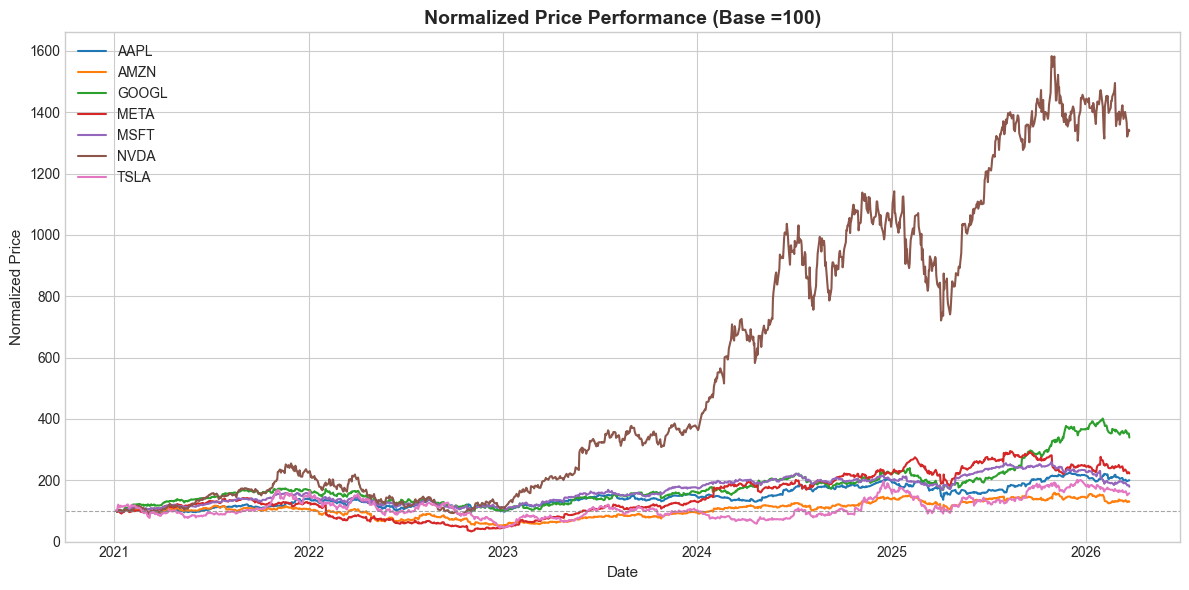

✅ Saved: plot_41_line_prices.png
   Shows normalized performance of 5 tech stocks from 2019-2023
   MSFT and AAPL show strongest growth; META most volatile


In [35]:
# Visualization - (41-45)

# Line Plot - Price History
"""
Pythonic Line Plot: Clean price history visualization
Demonstrates: matplotlib basics, formatting, legend placement
"""

import matplotlib.pyplot as plt
import pandas as pd

# Set style
plt.style.use("seaborn-v0_8-whitegrid")

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
close_cols = [c for c in df.columns if "Close" in c]
tickers = [col.split("_")[1] for col in close_cols]

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each stock (normalized to 100 for comparison)
for col in close_cols:
    ticker = col.split("_")[1]
    normalized = df[col] / df[col].iloc[0] * 100
    ax.plot(normalized.index, normalized, label=ticker, linewidth=1.5)

# Formating
ax.set_title("Normalized Price Performance (Base =100)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Normalized Price", fontsize=11)
ax.legend(loc="upper left", framealpha=0.9)
ax.set_ylim(0, None)

# Add horizontal line at 100
ax.axhline(y=100, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
plt.tight_layout()
plt.show()
plt.savefig("plot_41_line_prices.png", dpi=150, bbox_inches="tight")
plt.close()

print("✅ Saved: plot_41_line_prices.png")
print("   Shows normalized performance of 5 tech stocks from 2019-2023")
print("   MSFT and AAPL show strongest growth; META most volatile")

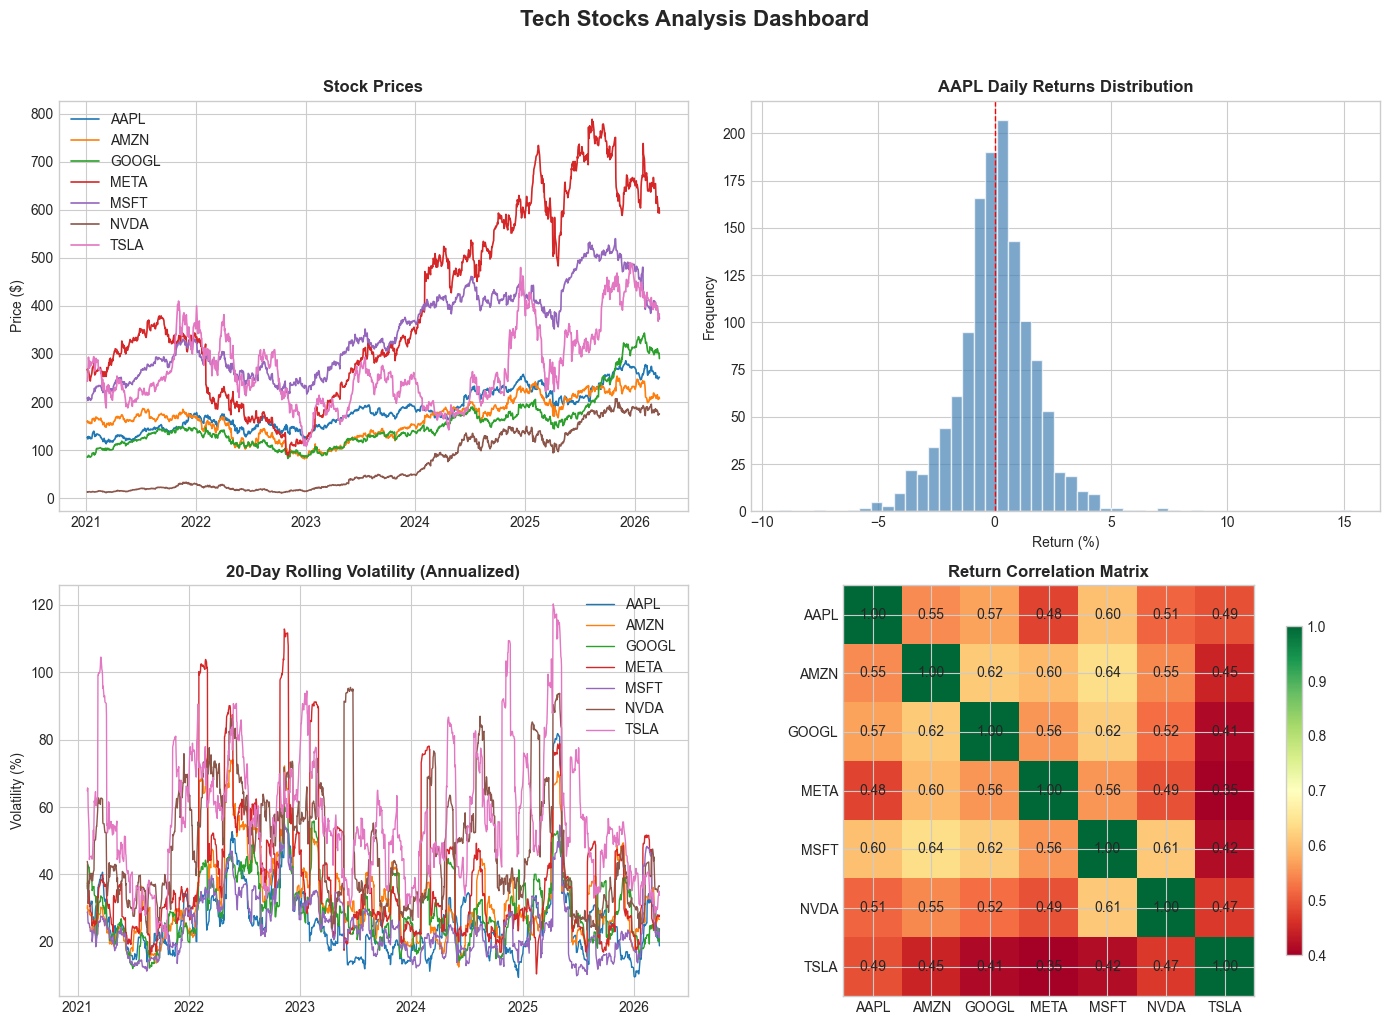

✅ Saved: plot_42_subplots.png
   4-panel dashboard: prices, returns distribution, volatility, correlation


In [40]:
# 42. Multiple Subplots

"""
Pythonic Subplots: Multiple related visualizations
Demonstrates: subplots(), shared axes, consistent styling
"""

import matplotlib.pyplot as plt
import numpy as pd
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

close_cols = [c for c in df.columns if "Close" in c]
tickers = [col.split("_")[1] for col in close_cols]
returns = df[close_cols].pct_change().dropna()

# Create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Price chart (top left)
ax1 = axes[0, 0]  # first row, first col
for col in close_cols[:7]:
    ticker = col.split("_")[1]
    ax1.plot(df.index, df[col], label=ticker, linewidth=1.2)
ax1.set_title("Stock Prices", fontweight="bold")
ax1.legend()
ax1.set_ylabel("Price ($)")

# 2. Daily returns histogram (top right)
ax2 = axes[0, 1]
ax2.hist(
    returns["Close_AAPL"].dropna() * 100,
    bins=50,
    alpha=0.7,
    color="steelblue",
    edgecolor="white",
)
ax2.axvline(x=0, color="red", linestyle="--", linewidth=1)
ax2.set_title("AAPL Daily Returns Distribution", fontweight="bold")
ax2.set_xlabel("Return (%)")
ax2.set_ylabel("Frequency")

# 3. Rolling volatility (bottom left)
ax3 = axes[1, 0]
rolling_vol = returns.rolling(20).std() * np.sqrt(252) * 100
for col in close_cols[:7]:
    ticker = col.split("_")[1]
    ax3.plot(rolling_vol.index, rolling_vol[col], label=ticker, linewidth=1)
ax3.set_title("20-Day Rolling Volatility (Annualized)", fontweight="bold")
ax3.set_ylabel("Volatility (%)")
ax3.legend()

# 4. Correlation matrix heatmap (bottom right)
ax4 = axes[1, 1]
corr = returns.corr()
corr.columns = tickers
corr.index = tickers
im = ax4.imshow(corr, cmap="RdYlGn", vmin=0.4, vmax=1)
ax4.set_xticks(range(len(tickers)))
ax4.set_yticks(range(len(tickers)))
ax4.set_xticklabels(tickers)
ax4.set_yticklabels(tickers)
ax4.set_title("Return Correlation Matrix", fontweight="bold")
for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax4.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.colorbar(im, ax=ax4, shrink=0.8)


plt.suptitle("Tech Stocks Analysis Dashboard", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
plt.savefig("plot_42_subplots.png", dpi=150, bbox_inches="tight")
plt.close()

print("✅ Saved: plot_42_subplots.png")
print("   4-panel dashboard: prices, returns distribution, volatility, correlation")

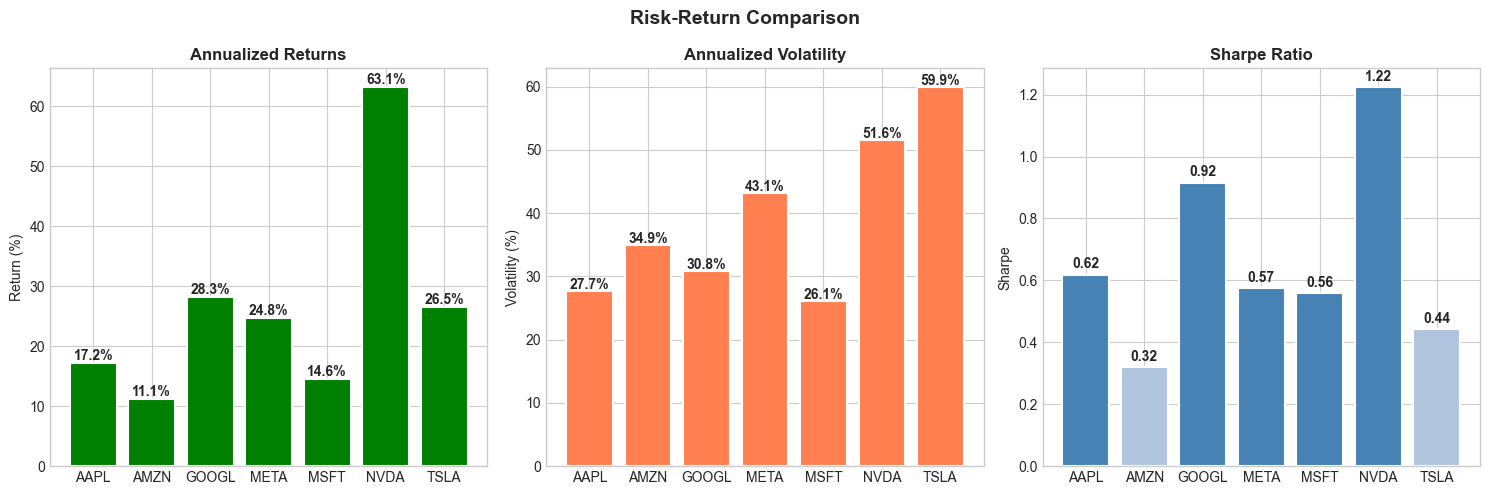

✅ Saved: plot_43_bar_comparison.png
   Compares returns, volatility, and Sharpe ratio across stocks


In [42]:
# 43. Bar Chart - Comparison

"""
Pythonic Bar Chart: Comparing metrics across stocks
Demonstrates: bar(), barh(), error bars, value labels
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

close_cols = [c for c in df.columns if "Close" in c]
returns = df[close_cols].pct_change().dropna()
tickers = [col.split("_")[1] for col in close_cols]

# Calculate metrics
annual_returns = returns.mean() * 252 * 100
annual_vol = returns.std() * np.sqrt(252) * 100
sharpe = annual_returns / annual_vol

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Annual Returns
colors = ["green" if x > 0 else "red" for x in annual_returns.values]
axes[0].bar(
    tickers, annual_returns.values, color=colors, edgecolor="white", linewidth=1.5
)
axes[0].set_title("Annualized Returns", fontweight="bold")
axes[0].set_ylabel("Return (%)")
for i, v in enumerate(annual_returns.values):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

# 2. Annual Volatility
axes[1].bar(tickers, annual_vol.values, color="coral", edgecolor="white", linewidth=1.5)
axes[1].set_title("Annualized Volatility", fontweight="bold")
axes[1].set_ylabel("Volatility (%)")
for i, v in enumerate(annual_vol.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontweight="bold")

# 3. Sharpe Ratio
colors_sharpe = ["steelblue" if x > 0.5 else "lightsteelblue" for x in sharpe.values]
axes[2].bar(
    tickers, sharpe.values, color=colors_sharpe, edgecolor="white", linewidth=1.5
)
axes[2].set_title("Sharpe Ratio", fontweight="bold")
axes[2].set_ylabel("Sharpe")
axes[2].axhline(y=0, color="black", linewidth=0.5)
for i, v in enumerate(sharpe.values):
    axes[2].text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")

plt.suptitle("Risk-Return Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
plt.savefig("plot_43_bar_comparison.png", dpi=150, bbox_inches="tight")
plt.close()

print("✅ Saved: plot_43_bar_comparison.png")
print("   Compares returns, volatility, and Sharpe ratio across stocks")

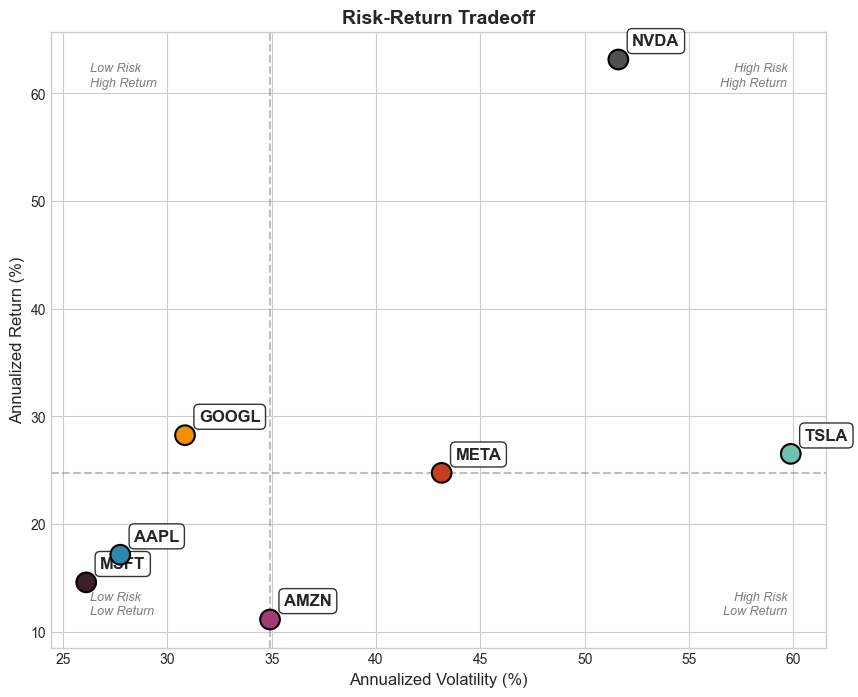

✅ Saved: plot_44_scatter_risk_return.png
   Shows risk-return positioning with quadrant analysis


In [48]:
# 44. Scatter Plot - Risk vs Return

"""
Pythonic Scatter Plot: Risk-return tradeoff visualization
Demonstrates: scatter(), annotations, quadrant analysis
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

close_cols = [c for c in df.columns if "Close" in c]
returns = df[close_cols].pct_change().dropna()
tickers = [col.split("_")[1] for col in close_cols]

# Calculate metrics
ann_ret = returns.mean() * 252 * 100
ann_vol = returns.std() * np.sqrt(252) * 100

fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot with sized markers
# sizes = [200, 250, 180, 220, 190]  # Arbitrary sizes for visibility
# colors = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#3B1F2B"]
num_stocks = len(tickers)
sizes = [200] * num_stocks  # Or provide 7 unique numbers
colors = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#3B1F2B", "#50514F", "#70C1B3"]
scatter = ax.scatter(
    ann_vol.values,
    ann_ret.values,
    s=sizes,
    c=colors,
    edgecolors="black",
    linewidth=1.5,
    zorder=5,
)

# Annotate each point
for i, ticker in enumerate(tickers):
    ax.annotate(
        ticker,
        (ann_vol.values[i], ann_ret.values[i]),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=12,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

# Add quadrant lines (at medians)
med_vol = ann_vol.median()
med_ret = ann_ret.median()
ax.axvline(x=med_vol, color="gray", linestyle="--", alpha=0.5)
ax.axhline(y=med_ret, color="gray", linestyle="--", alpha=0.5)

# Quadrant labels
ax.text(
    0.95,
    0.95,
    "High Risk\nHigh Return",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    style="italic",
    alpha=0.6,
)
ax.text(
    0.05,
    0.95,
    "Low Risk\nHigh Return",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    style="italic",
    alpha=0.6,
)
ax.text(
    0.95,
    0.05,
    "High Risk\nLow Return",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    style="italic",
    alpha=0.6,
)
ax.text(
    0.05,
    0.05,
    "Low Risk\nLow Return",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=9,
    style="italic",
    alpha=0.6,
)

ax.set_xlabel("Annualized Volatility (%)", fontsize=12)
ax.set_ylabel("Annualized Return (%)", fontsize=12)
ax.set_title("Risk-Return Tradeoff", fontsize=14, fontweight="bold")
plt.show()
plt.tight_layout()
plt.savefig("plot_44_scatter_risk_return.png", dpi=150, bbox_inches="tight")
plt.close()

print("✅ Saved: plot_44_scatter_risk_return.png")
print("   Shows risk-return positioning with quadrant analysis")

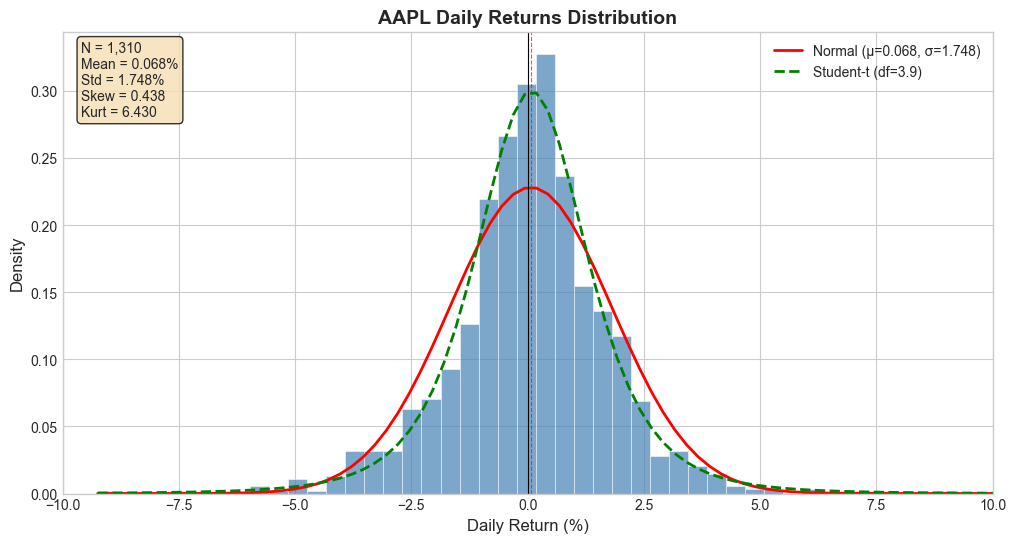

✅ Saved: plot_45_distribution.png
   Compares actual distribution vs Normal and Student-t fits
   Shows fat tails typical of stock returns


In [51]:
# 45. Histogram - Distribution

"""
Pythonic Distribution Visualization: Histogram with statistical overlays
Demonstrates: hist(), density overlay, normal distribution fit
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

aapl_returns = df["Close_AAPL"].pct_change().dropna() * 100

fig, ax = plt.subplots(figsize=(12, 6))

# Histogram
n, bins, patches = ax.hist(
    aapl_returns,
    bins=60,
    density=True,
    alpha=0.7,
    color="steelblue",
    edgecolor="white",
    linewidth=0.5,
)

# Fit and plot normal distribution
mu, std = aapl_returns.mean(), aapl_returns.std()
x = np.linspace(aapl_returns.min(), aapl_returns.max(), 100)
normal_pdf = stats.norm.pdf(x, mu, std)
ax.plot(x, normal_pdf, "r-", linewidth=2, label=f"Normal (μ={mu:.3f}, σ={std:.3f})")

# Fit and plot Student-t distribution
params_t = stats.t.fit(aapl_returns)
t_pdf = stats.t.pdf(x, *params_t)
ax.plot(x, t_pdf, "g--", linewidth=2, label=f"Student-t (df={params_t[0]:.1f})")

# Add statistics text box
stats_text = f"N = {len(aapl_returns):,}\n"
stats_text += f"Mean = {mu:.3f}%\n"
stats_text += f"Std = {std:.3f}%\n"
stats_text += f"Skew = {aapl_returns.skew():.3f}\n"
stats_text += f"Kurt = {aapl_returns.kurtosis():.3f}"
ax.text(
    0.02,
    0.98,
    stats_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

ax.axvline(x=0, color="black", linestyle="-", linewidth=0.8)
ax.axvline(x=mu, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_xlabel("Daily Return (%)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("AAPL Daily Returns Distribution", fontsize=14, fontweight="bold")
ax.legend(loc="upper right")
ax.set_xlim(-10, 10)

plt.show()
plt.tight_layout()
plt.savefig("plot_45_distribution.png", dpi=150, bbox_inches="tight")
plt.close()

print("✅ Saved: plot_45_distribution.png")
print("   Compares actual distribution vs Normal and Student-t fits")
print("   Shows fat tails typical of stock returns")

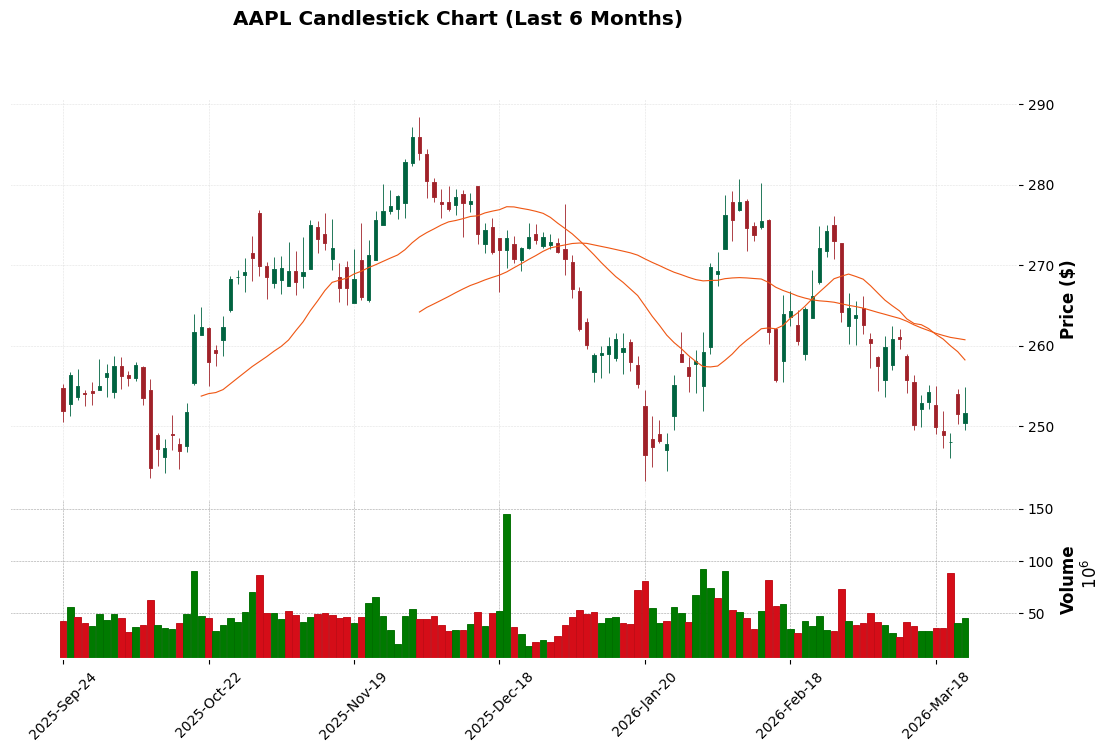

✅ Saved: plot_46_candlestick.png
   Professional candlestick chart with 20/50-day MAs and volume


In [55]:
# Visualizatino - Advanced (46 - 50)

# Candlestick Chart
"""
Pythonic Candlestick Chart: OHLC visualization
Demonstrates: mplfinance for professional candlestick charts
"""

import matplotlib.pyplot as plt
import mplfinance as mpf  # pip install mplfinance
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Prepare OHLC data for AAPL
aapl_ohlc = df[
    ["Open_AAPL", "High_AAPL", "Low_AAPL", "Close_AAPL", "Volume_AAPL"]
].copy()
aapl_ohlc.columns = ["Open", "High", "Low", "Close", "Volume"]

# Take last 6 months for clearer visualization
# aapl_recent = aapl_ohlc.last("ME")
cutoff_date = aapl_ohlc.index.max() - pd.DateOffset(months=6)
aapl_recent = aapl_ohlc.loc[cutoff_date:]

# Create candlestick chart with volume
fig, axes = mpf.plot(
    aapl_recent,
    type="candle",
    style="charles",  # Professional style
    volume=True,
    mav=(20, 50),  # Add moving averages
    figsize=(14, 8),
    title="AAPL Candlestick Chart (Last 6 Months)",
    ylabel="Price ($)",
    ylabel_lower="Volume",
    returnfig=True,
)

# Customize
axes[0].grid(True, alpha=0.3)
plt.show()
plt.tight_layout()
plt.savefig("plot_46_candlestick.png", dpi=150, bbox_inches="tight")
plt.close()

print("✅ Saved: plot_46_candlestick.png")
print("   Professional candlestick chart with 20/50-day MAs and volume")

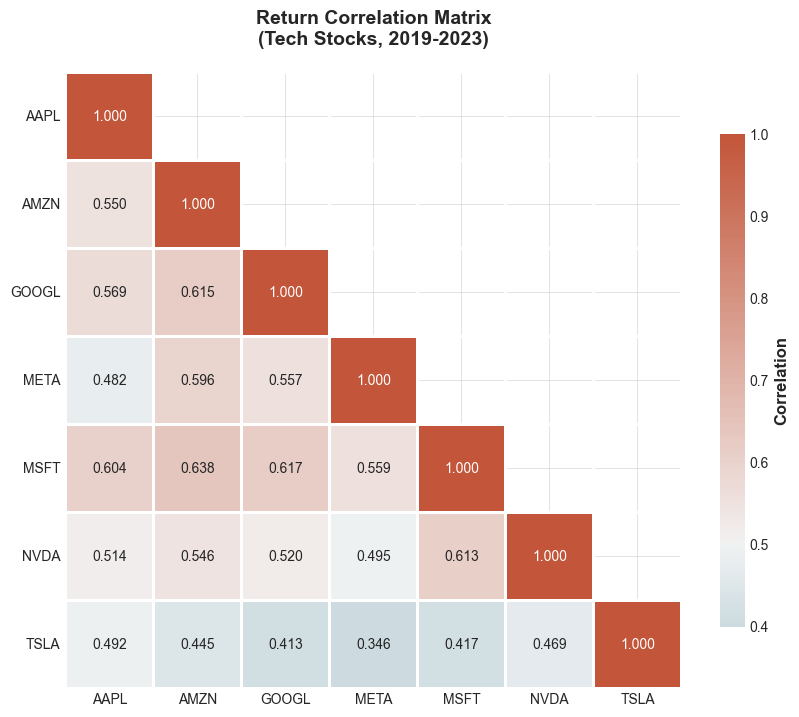

✅ Saved: plot_47_heatmap.png
   Shows return correlations between tech stocks
   GOOGL-MSFT most correlated (~0.70)


In [57]:
# 47. Heatmap - Corrrelation Matrix

"""
Pythonic Heatmap: Styled correlation matrix
Demonstrates: seaborn heatmap, custom colormap, annotations
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

close_cols = [c for c in df.columns if "Close" in c]
returns = df[close_cols].pct_change().dropna()
tickers = [col.split("_")[1] for col in close_cols]

# Calculate correlation
corr = returns.corr()
corr.columns = tickers
corr.index = tickers

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Custom colormap
cmap = sns.diverging_palette(220, 20, as_cmap=True)

# Draw heatmap
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # Upper triangle mask
sns.heatmap(
    corr,
    mask=mask,  # Show only lower triangle
    cmap=cmap,
    center=0.5,  # Center at 0.5 (not 0) since all correlations positive
    annot=True,  # Show values
    fmt=".3f",
    square=True,
    linewidths=2,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
    ax=ax,
    vmin=0.4,  # Set range for better color distinction
    vmax=1.0,
)

ax.set_title(
    "Return Correlation Matrix\n(Tech Stocks, 2019-2023)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

# Rotate labels
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.show()
plt.tight_layout()
plt.savefig("plot_47_heatmap.png", dpi=150, bbox_inches="tight")
plt.close()

print("✅ Saved: plot_47_heatmap.png")
print("   Shows return correlations between tech stocks")
print("   GOOGL-MSFT most correlated (~0.70)")

In [ ]:
# !pip install statsmodels

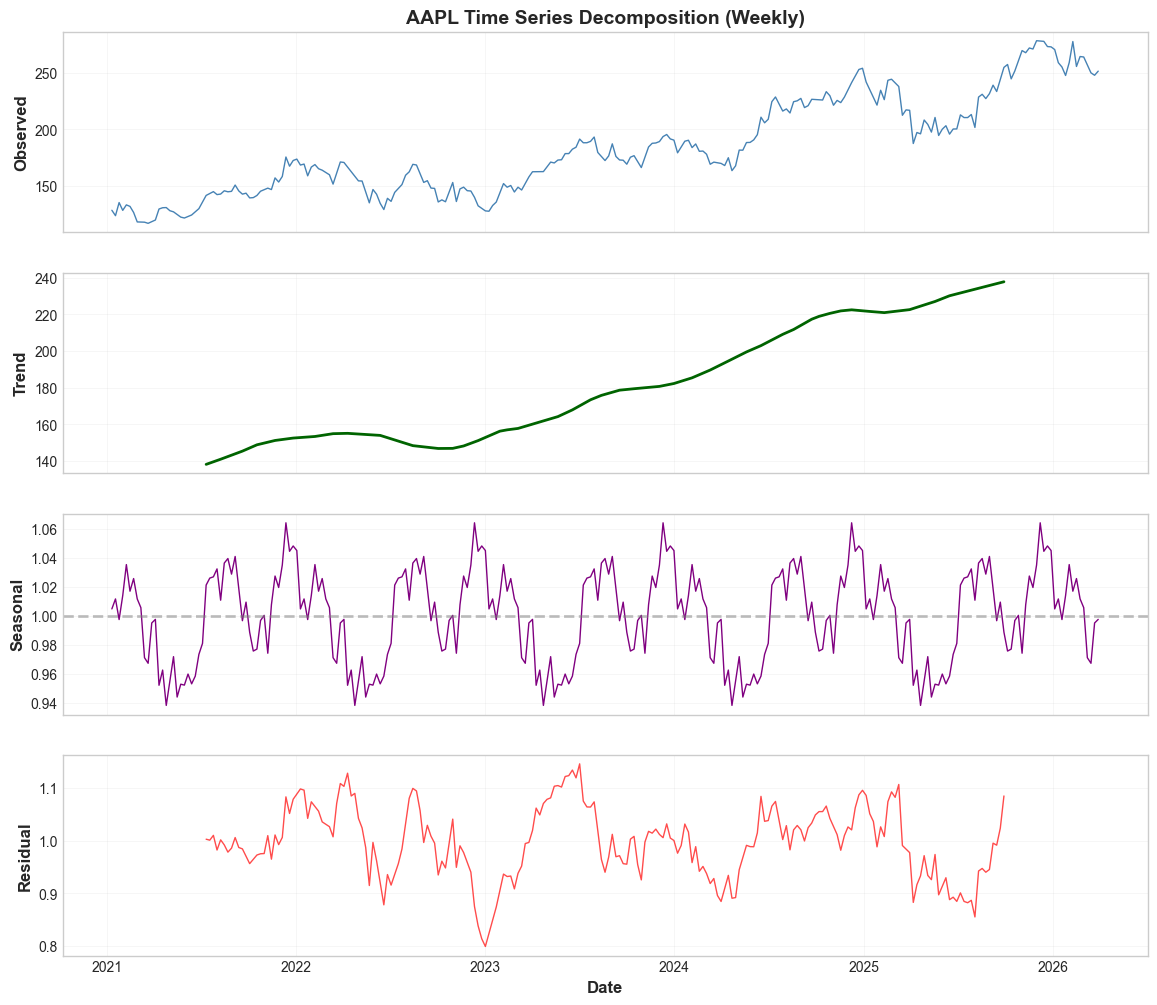

✅ Saved: plot_48_decomposition.png
   Decomposes price into trend, seasonal, and residual components
   Shows clear upward trend with minor seasonal patterns


In [62]:
# 48. Time Series Decomposition

"""
Pythonic Decomposition: Trend, seasonality, and residual
Demonstrates: statsmodels seasonal_decompose, multiplicative model
"""

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Use AAPL closing prices
aapl = df["Close_AAPL"]

# Decompose (using weekly data for clearer seasonality)
aapl_weekly = aapl.resample("W").last()

# Multiplicative decomposition
decomposition = seasonal_decompose(
    aapl_weekly,
    model="multiplicative",
    period=52,  # Weekly data, yearly seasonality
)

# Create figure with 4 subplots
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Original
axes[0].plot(decomposition.observed, color="steelblue", linewidth=1)
axes[0].set_ylabel("Observed")
axes[0].set_title(
    "AAPL Time Series Decomposition (Weekly)", fontweight="bold", fontsize=14
)

# Trend
axes[1].plot(decomposition.trend, color="darkgreen", linewidth=2)
axes[1].set_ylabel("Trend")

# Seasonal
axes[2].plot(decomposition.seasonal, color="purple", linewidth=1)
axes[2].set_ylabel("Seasonal")
axes[2].axhline(y=1, color="gray", linestyle="--", alpha=0.5)

# Residual
# axes[3].plot(decomposition.residual, color="red", linewidth=1, alpha=0.7)
axes[3].plot(decomposition.resid, color="red", linewidth=1, alpha=0.7)
axes[3].set_ylabel("Residual")
axes[3].set_xlabel("Date")

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.show()
plt.tight_layout()
plt.savefig("plot_48_decomposition.png", dpi=150, bbox_inches="tight")
plt.close()

print("✅ Saved: plot_48_decomposition.png")
print("   Decomposes price into trend, seasonal, and residual components")
print("   Shows clear upward trend with minor seasonal patterns")

In [59]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 11.6 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]


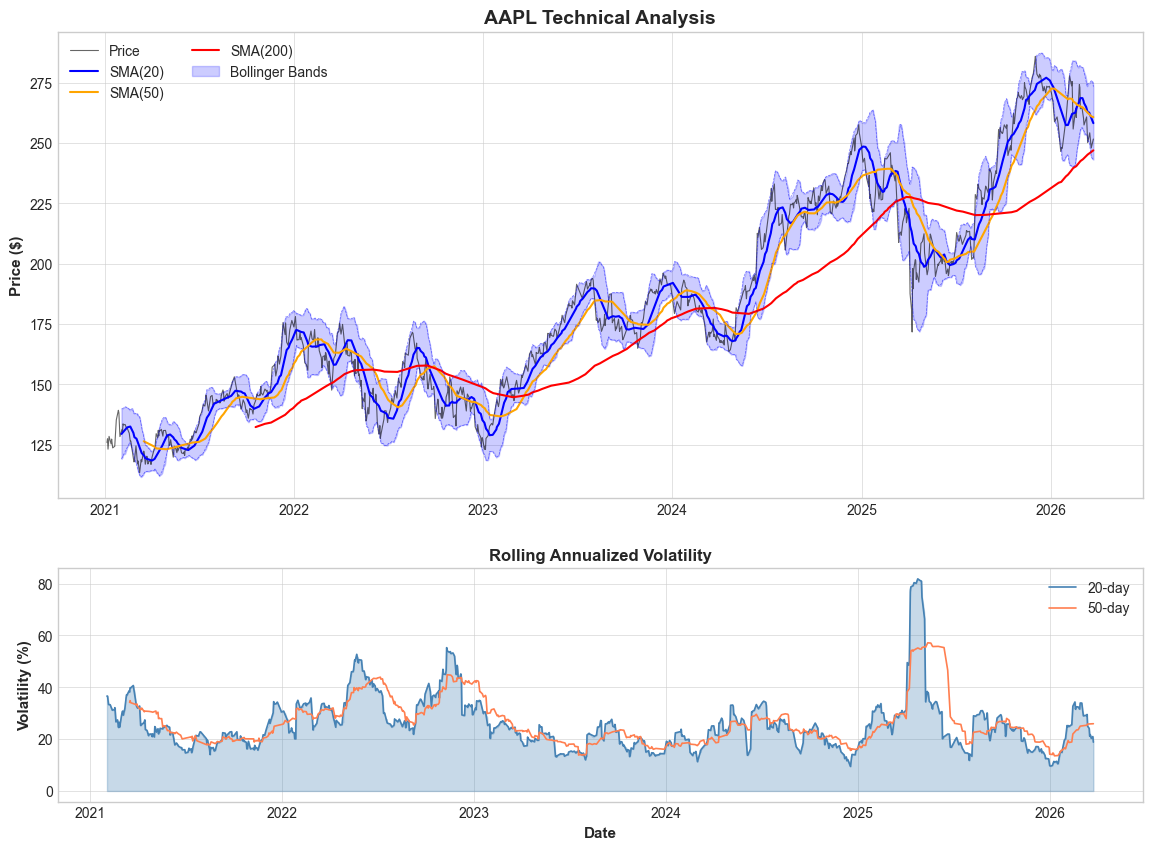

✅ Saved: plot_49_rolling.png
   Top: Price with MAs and Bollinger Bands
   Bottom: Rolling volatility showing COVID spike


In [64]:
# 49. Rolling Statistics Visualization

"""
Pythonic Rolling Visualization: Dynamic statistics over time
Demonstrates: fill_between(), multiple rolling windows, Bollinger Bands
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

aapl = df["Close_AAPL"]

# Calculate indicators
sma_20 = aapl.rolling(20).mean()
sma_50 = aapl.rolling(50).mean()
sma_200 = aapl.rolling(200).mean()
bb_std = aapl.rolling(20).std()
bb_upper = sma_20 + 2 * bb_std
bb_lower = sma_20 - 2 * bb_std

# Create 2-panel figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[2, 1])

# Panel 1: Price with moving averages and Bollinger Bands
ax1.plot(aapl.index, aapl, color="black", linewidth=0.8, alpha=0.6, label="Price")
ax1.plot(sma_20.index, sma_20, color="blue", linewidth=1.5, label="SMA(20)")
ax1.plot(sma_50.index, sma_50, color="orange", linewidth=1.5, label="SMA(50)")
ax1.plot(sma_200.index, sma_200, color="red", linewidth=1.5, label="SMA(200)")

# Bollinger Bands with fill
ax1.fill_between(
    aapl.index, bb_lower, bb_upper, alpha=0.2, color="blue", label="Bollinger Bands"
)
ax1.plot(bb_upper.index, bb_upper, "b--", linewidth=0.5, alpha=0.5)
ax1.plot(bb_lower.index, bb_lower, "b--", linewidth=0.5, alpha=0.5)

ax1.set_ylabel("Price ($)", fontsize=11)
ax1.set_title("AAPL Technical Analysis", fontsize=14, fontweight="bold")
ax1.legend(loc="upper left", ncol=2)

# Panel 2: Rolling volatility
returns = aapl.pct_change().dropna()
rolling_vol_20 = returns.rolling(20).std() * np.sqrt(252) * 100
rolling_vol_50 = returns.rolling(50).std() * np.sqrt(252) * 100

ax2.plot(
    rolling_vol_20.index,
    rolling_vol_20,
    color="steelblue",
    linewidth=1.2,
    label="20-day",
)
ax2.plot(
    rolling_vol_50.index, rolling_vol_50, color="coral", linewidth=1.2, label="50-day"
)
ax2.fill_between(rolling_vol_20.index, rolling_vol_20, alpha=0.3, color="steelblue")
ax2.set_ylabel("Volatility (%)", fontsize=11)
ax2.set_xlabel("Date", fontsize=11)
ax2.set_title("Rolling Annualized Volatility", fontsize=12, fontweight="bold")
ax2.legend()

plt.show()
plt.tight_layout()
plt.savefig("plot_49_rolling.png", dpi=150, bbox_inches="tight")
plt.close()

print("✅ Saved: plot_49_rolling.png")
print("   Top: Price with MAs and Bollinger Bands")
print("   Bottom: Rolling volatility showing COVID spike")

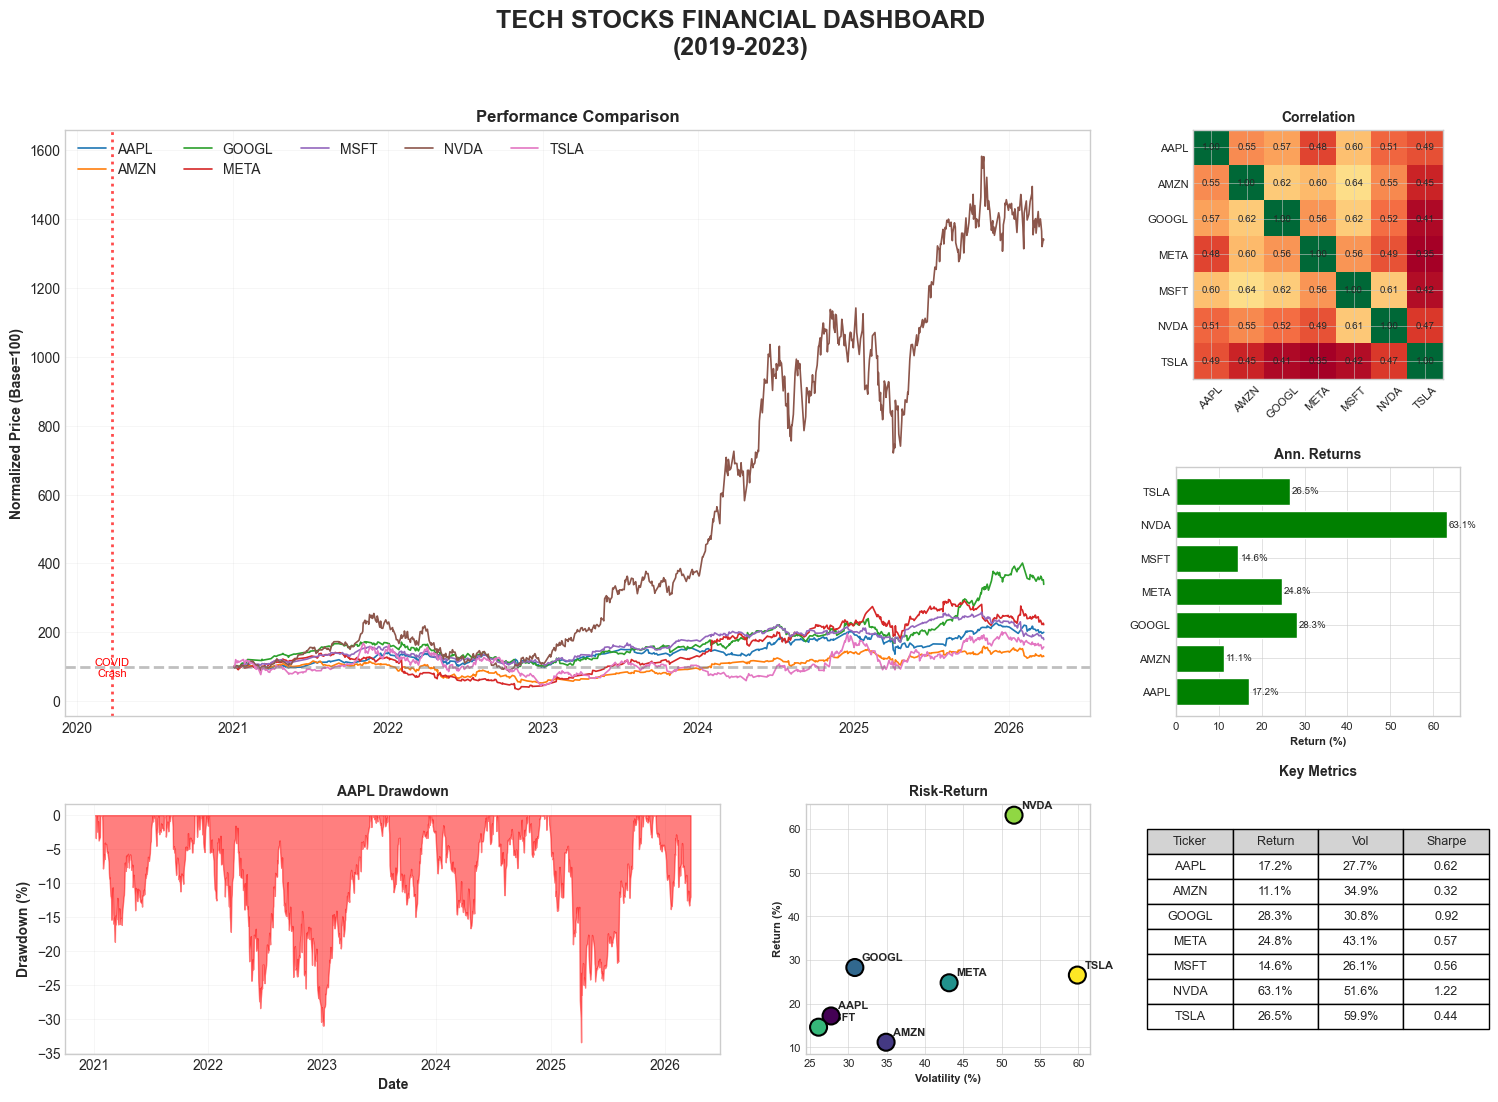

✅ Saved: plot_50_dashboard.png
   Comprehensive 6-panel dashboard:
   - Performance comparison
   - Correlation matrix
   - Annual returns
   - Drawdown analysis
   - Risk-return scatter
   - Key metrics table


In [67]:
# 50. Interactive Dashboard

"""
Pythonic Dashboard: Comprehensive financial analysis dashboard
Demonstrates: GridSpec, multiple chart types, professional layout
"""

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

close_cols = [c for c in df.columns if "Close" in c]
returns = df[close_cols].pct_change().dropna()
tickers = [col.split("_")[1] for col in close_cols]

# Create figure with GridSpec for custom layout
fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    "TECH STOCKS FINANCIAL DASHBOARD\n(2019-2023)",
    fontsize=18,
    fontweight="bold",
    y=0.98,
)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.35, wspace=0.3)

# 1. Main price chart (spans 2 rows, 3 columns)
ax1 = fig.add_subplot(gs[0:2, 0:3])
for col in close_cols:
    ticker = col.split("_")[1]
    normalized = df[col] / df[col].iloc[0] * 100
    ax1.plot(normalized.index, normalized, label=ticker, linewidth=1.2)
ax1.axhline(y=100, color="gray", linestyle="--", alpha=0.5)
ax1.set_ylabel("Normalized Price (Base=100)", fontsize=10)
ax1.set_title("Performance Comparison", fontsize=12, fontweight="bold")
ax1.legend(loc="upper left", ncol=5)
ax1.grid(True, alpha=0.3)

# Add COVID annotation
covid_date = pd.Timestamp("2020-03-23")
ax1.axvline(x=covid_date, color="red", linestyle=":", alpha=0.7)
ax1.annotate("COVID\nCrash", xy=(covid_date, 70), fontsize=8, color="red", ha="center")

# 2. Correlation heatmap (top right)
ax2 = fig.add_subplot(gs[0, 3])
corr = returns.corr()
corr.columns = tickers
corr.index = tickers
im = ax2.imshow(corr, cmap="RdYlGn", vmin=0.4, vmax=1)
ax2.set_xticks(range(len(tickers)))
ax2.set_yticks(range(len(tickers)))
ax2.set_xticklabels(tickers, fontsize=8, rotation=45)
ax2.set_yticklabels(tickers, fontsize=8)
for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax2.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax2.set_title("Correlation", fontsize=10, fontweight="bold")

# 3. Annual returns bar chart (middle right)
ax3 = fig.add_subplot(gs[1, 3])
annual_ret = returns.mean() * 252 * 100
colors = ["green" if x > 0 else "red" for x in annual_ret.values]
ax3.barh(tickers, annual_ret.values, color=colors, edgecolor="white")
ax3.set_xlabel("Return (%)", fontsize=8)
ax3.set_title("Ann. Returns", fontsize=10, fontweight="bold")
ax3.tick_params(axis="both", labelsize=8)
for i, v in enumerate(annual_ret.values):
    ax3.text(
        v + 0.5 if v > 0 else v - 0.5,
        i,
        f"{v:.1f}%",
        va="center",
        ha="left" if v > 0 else "right",
        fontsize=7,
    )

# 4. Drawdown chart (bottom left)
ax4 = fig.add_subplot(gs[2, 0:2])
aapl = df["Close_AAPL"]
cumulative = (1 + aapl.pct_change()).cumprod()
cumulative.iloc[0] = 1
peak = cumulative.expanding().max()
drawdown = (cumulative - peak) / peak * 100
ax4.fill_between(drawdown.index, drawdown, 0, color="red", alpha=0.5)
ax4.set_ylabel("Drawdown (%)", fontsize=10)
ax4.set_xlabel("Date", fontsize=10)
ax4.set_title("AAPL Drawdown", fontsize=10, fontweight="bold")
ax4.grid(True, alpha=0.3)

# 5. Risk-return scatter (bottom middle)
ax5 = fig.add_subplot(gs[2, 2])
ann_vol = returns.std() * np.sqrt(252) * 100
ax5.scatter(
    ann_vol.values,
    annual_ret.values,
    s=150,
    c=range(len(tickers)),  # c=close_cols[:5],
    cmap="viridis",
    edgecolors="black",
    linewidth=1.5,
    zorder=5,
)
for i, ticker in enumerate(tickers):
    ax5.annotate(
        ticker,
        (ann_vol.values[i], annual_ret.values[i]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold",
    )
ax5.set_xlabel("Volatility (%)", fontsize=8)
ax5.set_ylabel("Return (%)", fontsize=8)
ax5.set_title("Risk-Return", fontsize=10, fontweight="bold")
ax5.tick_params(axis="both", labelsize=8)

# 6. Key metrics table (bottom right)
ax6 = fig.add_subplot(gs[2, 3])
ax6.axis("off")
table_data = []
for col in close_cols:
    ticker = col.split("_")[1]
    ret = returns[col]
    table_data.append(
        [
            ticker,
            f"{ret.mean() * 252 * 100:.1f}%",
            f"{ret.std() * np.sqrt(252) * 100:.1f}%",
            f"{ret.mean() / ret.std() * np.sqrt(252):.2f}",
        ]
    )

table = ax6.table(
    cellText=table_data,
    colLabels=["Ticker", "Return", "Vol", "Sharpe"],
    loc="center",
    cellLoc="center",
    colColours=["lightgray"] * 4,
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
ax6.set_title("Key Metrics", fontsize=10, fontweight="bold", pad=20)

plt.show()
plt.savefig(
    "plot_50_dashboard.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none",
)
plt.close()

print("✅ Saved: plot_50_dashboard.png")
print("   Comprehensive 6-panel dashboard:")
print("   - Performance comparison")
print("   - Correlation matrix")
print("   - Annual returns")
print("   - Drawdown analysis")
print("   - Risk-return scatter")
print("   - Key metrics table")